In [1]:

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
import fitsio
import numpy as np
import Corrfunc
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.io import read_catalog
from Corrfunc.utils import convert_3d_counts_to_cf
from astropy.table import Table
import pyccl as ccl
import healpy as hp
random_compiled = fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_5M.fits')[1].read()[:5000000]
rand_table=Table(random_compiled)
import pyarrow.parquet as pq

import pyarrow as pa
import scienceplots
plt.style.use(['science','notebook','grid'])

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [27]:


rand_table = rand_table[rand_table['DEC'] > -30]
table_selection = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/table_north_unique_zpt_shifted_00234.fits')[1].read())
#table_selection = Table(fitsio.FITS('table_match_final.fits')[1].read())
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
RA_random,DEC_random = rand_table['RA'], rand_table['DEC']  
RA_data   = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
DEC_data  = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))
RA_random = np.ascontiguousarray(np.array(RA_random, dtype=np.float64))
DEC_random= np.ascontiguousarray(np.array(DEC_random, dtype=np.float64))
rand_N = len(RA_random)
nbins = 10
bins = np.linspace(0.1, 10.0, nbins + 1) # note the +1 to nbins
nthreads = 190
autocorr=1
N=len(RA_data)
print('Starting code')
DD_counts = DDtheta_mocks(autocorr, nthreads, bins,

                         RA_data, DEC_data)


autocorr=0
print('Done with DD coutns')

DR_counts = DDtheta_mocks(autocorr, nthreads, bins,

                          RA_data, DEC_data,

                          RA2=RA_random, DEC2=DEC_random)

# Auto pairs counts in RR

autocorr=1
print('Done with DR counts')

RR_counts = DDtheta_mocks(autocorr, nthreads, bins,

                          RA_random,DEC_random)

print('Done with RR counts')
wtheta = convert_3d_counts_to_cf(N, N, rand_N, rand_N,

                                DD_counts, DR_counts,

                                DR_counts, RR_counts,estimator='Landy')

import pickle
# with open('wtheta_3.pkl', 'wb') as f:
#     pickle.dump(wtheta, f)
print('RR counts',RR_counts)
print('DR counts',DR_counts)
print('DD counts',DD_counts)
# with open('RR_counts_3.pkl', 'wb') as f:
#     pickle.dump(RR_counts, f)

Starting code
Done with DD coutns
Done with DR counts
Done with RR counts
RR counts [(0.1 ,  1.09, 0.,  350294002, 0.) (1.09,  2.08, 0.,  918437590, 0.)
 (2.08,  3.07, 0., 1466658064, 0.) (3.07,  4.06, 0., 1994541238, 0.)
 (4.06,  5.05, 0., 2502674300, 0.) (5.05,  6.04, 0., 2990788490, 0.)
 (6.04,  7.03, 0., 3459181520, 0.) (7.03,  8.02, 0., 3907115406, 0.)
 (8.02,  9.01, 0., 4335314574, 0.) (9.01, 10.  , 0., 4744011116, 0.)]
DR counts [(0.1 ,  1.09, 0.,  70712906, 0.) (1.09,  2.08, 0., 185532465, 0.)
 (2.08,  3.07, 0., 295942674, 0.) (3.07,  4.06, 0., 401976771, 0.)
 (4.06,  5.05, 0., 503414698, 0.) (5.05,  6.04, 0., 600677893, 0.)
 (6.04,  7.03, 0., 694132369, 0.) (7.03,  8.02, 0., 782948284, 0.)
 (8.02,  9.01, 0., 867082156, 0.) (9.01, 10.  , 0., 947298039, 0.)]
DD counts [(0.1 ,  1.09, 0.,  17232484, 0.) (1.09,  2.08, 0.,  41334222, 0.)
 (2.08,  3.07, 0.,  63860340, 0.) (3.07,  4.06, 0.,  85077834, 0.)
 (4.06,  5.05, 0., 105109502, 0.) (5.05,  6.04, 0., 124032574, 0.)
 (6.04,  7.03

In [3]:
def prepare_coords(ra_deg, dec_deg):
    ra_rad = np.radians(ra_deg)
    ra_rad = np.remainder(ra_rad + 2*np.pi, 2*np.pi)  # Normalize to [0, 2π]
    ra_rad[ra_rad > np.pi] -= 2*np.pi                # Shift to [-π, π]
    ra_rad = -ra_rad                                  # Flip for Mollweide
    dec_rad = np.radians(dec_deg)
    return ra_rad, dec_rad    


In [4]:
12*6**2

432

In [4]:
def hist_pix(ra,dec,nside=6):
    npix = hp.nside2npix(nside)
    pix = hp.ang2pix(nside, np.radians(90.-dec), np.radians(ra), lonlat=False)
    counts = np.bincount(pix, minlength=npix)
    return counts

In [5]:
def pixelize(ra,dec,nside=6):
    theta = np.ascontiguousarray((np.pi/2.0 - np.deg2rad(dec)).astype(np.float64))
    phi   = np.ascontiguousarray(np.deg2rad(ra).astype(np.float64))

    hpix = hp.ang2pix(nside, theta, phi,nest=False)
    return hpix

In [7]:
# for i in range(len(hpix)):
#     mask = hpix != 30
#     subset_data_ra, subset_data_dec = RA_data[mask], DEC_data[mask]
#     subset_random_ra, subset_random_dec = RA_random[mask], DEC_random[mask]
#     break

In [8]:
# import numpy as np

# # Your pair counts (arrays with length = number of bins)
# # Example placeholders: replace with your actual outputs
# # DD_counts, DR_counts, RR_counts = ...

# # Catalog sizes (needed for normalization)
# ND = N         # number of data points
# NR = rand_N    # number of random points

# # Normalization factors
# fN = NR / ND

# # Landy–Szalay estimator for auto-correlation
# nonzero = RR > 0
# wtheta = np.full_like(RR, np.nan, dtype=float)

# wtheta[nonzero] = (fN * fN * DD[nonzero] -
#                    2.0 * fN * DR[nonzero] +
#                    RR[nonzero]) / RR[nonzero]

# # Print results
# for i, val in enumerate(wtheta):
#     print(f"Bin {i}: w(theta) = {val:.6f}")

# # If you only want the arrays:
# print("RR counts:", RR_counts)
# print("DR counts:", DR_counts)
# print("DD counts:", DD_counts)
# print("w(theta):", wtheta)


In [9]:
# from scipy.optimize import curve_fit as cf
# popt,pcov=cf(dll,bin_centers[bin_centers<300],Cl[bin_centers<300],sigma=dCl[bin_centers<300],p0=[2])
# popt
# plt.plot(l,dll(*popt,l),label='Bestfit from pyccl')
# plt.errorbar(bin_centers,Cl,yerr=dCl,ls='None',marker='.',color='g')
# #plt.plot(l,dll(35,l))
# plt.xlim(0,300)
# plt.ylim(0,0.5)
# plt.ylabel(r'$D_l$')
# plt.xlabel('l')
# plt.legend()

In [10]:
# DR=DR_counts['npairs']
# DD=DD_counts['npairs']
# RR=RR_counts['npairs']
# pairs_DD = N * (N - 1) / 2.0
# pairs_RR = rand_N * (rand_N - 1) / 2.0
# pairs_DR = N * rand_N
# DDn = DD.astype(float) / pairs_DD
# DRn = DR.astype(float) / pairs_DR
# RRn = RR.astype(float) / pairs_RR

In [11]:
# import numpy as np

# # arrays of raw counts (length = n_bins)

# ND = N    # data
# NR = rand_N
# fN = NR / NDselection_FP.py
# A = fN**2
# B = fN

# nonzero = RR > 0
# w = np.full_like(RR, np.nan, dtype=float)
# w[nonzero] = (A*DD[nonzero] - 2*B*DR[nonzero] + RR[nonzero]) / RR[nonzero]

# # Poisson variances
# VarX = DD
# VarY = DR
# VarZ = RR

# sigma2 = np.full_like(RR, np.nan, dtype=float)
# sigma2[nonzero] = ((A/RR[nonzero])**2 * VarX[nonzero] +
#                    (2*B/RR[nonzero])**2 * VarY[nonzero] +
#                    ((A*DD[nonzero] - 2*B*DR[nonzero]) / RR[nonzero]**2)**2 * VarZ[nonzero])
# sigma = np.sqrt(sigma2)
# sigma

In [12]:
# estimator = ((rand_N/N)**(2)*DD - 2 *(rand_N/N)*DR + RR) / (RR)
# estimator_naive = (DDn - RRn) / (RRn)

5000000
RR counts [(0.1 ,  1.09, 0.,  1678230158, 0.) (1.09,  2.08, 0.,  4457055236, 0.)
 (2.08,  3.07, 0.,  7216866596, 0.) (3.07,  4.06, 0.,  9957231996, 0.)
 (4.06,  5.05, 0., 12676497466, 0.) (5.05,  6.04, 0., 15374222802, 0.)
 (6.04,  7.03, 0., 18050303696, 0.) (7.03,  8.02, 0., 20702620264, 0.)
 (8.02,  9.01, 0., 23331047060, 0.) (9.01, 10.  , 0., 25935134268, 0.)]
DR counts [(0.1 ,  1.09, 0.,  215400492, 0.) (1.09,  2.08, 0.,  572833043, 0.)
 (2.08,  3.07, 0.,  928876365, 0.) (3.07,  4.06, 0., 1283918022, 0.)
 (4.06,  5.05, 0., 1637351386, 0.) (5.05,  6.04, 0., 1989409904, 0.)
 (6.04,  7.03, 0., 2339965813, 0.) (7.03,  8.02, 0., 2689003784, 0.)
 (8.02,  9.01, 0., 3035998222, 0.) (9.01, 10.  , 0., 3380952944, 0.)]
DD counts [(0.1 ,  1.09, 0.,  61459558, 0.) (1.09,  2.08, 0., 146902838, 0.)
 (2.08,  3.07, 0., 228529714, 0.) (3.07,  4.06, 0., 306345828, 0.)
 (4.06,  5.05, 0., 380512734, 0.) (5.05,  6.04, 0., 453687466, 0.)
 (6.04,  7.03, 0., 524348694, 0.) (7.03,  8.02, 0., 593098740, 0.)
 (8.02,  9.01, 0., 659364262, 0.) (9.01, 10.  , 0., 723956844, 0.)]
 array([1.22516035, 0.99978168, 0.91821674, 0.8598438 , 0.81085192,
       0.77632737, 0.74464379, 0.71635169, 0.68906335, 0.66429289])

2500000
RR counts [(0.1 ,  1.09, 0.,  419309670, 0.) (1.09,  2.08, 0., 1113550742, 0.)
 (2.08,  3.07, 0., 1803012418, 0.) (3.07,  4.06, 0., 2487618858, 0.)
 (4.06,  5.05, 0., 3166860102, 0.) (5.05,  6.04, 0., 3840762762, 0.)
 (6.04,  7.03, 0., 4509205290, 0.) (7.03,  8.02, 0., 5171862092, 0.)
 (8.02,  9.01, 0., 5828096768, 0.) (9.01, 10.  , 0., 6478370978, 0.)]
DR counts [(0.1 ,  1.09, 0.,  107634971, 0.) (1.09,  2.08, 0.,  286283632, 0.)
 (2.08,  3.07, 0.,  464247152, 0.) (3.07,  4.06, 0.,  641724163, 0.)
 (4.06,  5.05, 0.,  818279002, 0.) (5.05,  6.04, 0.,  994268546, 0.)
 (6.04,  7.03, 0., 1169489029, 0.) (7.03,  8.02, 0., 1343918511, 0.)
 (8.02,  9.01, 0., 1517504830, 0.) (9.01, 10.  , 0., 1689972483, 0.)]
DD counts [(0.1 ,  1.09, 0.,  61459558, 0.) (1.09,  2.08, 0., 146902838, 0.)
 (2.08,  3.07, 0., 228529714, 0.) (3.07,  4.06, 0., 306345828, 0.)
 (4.06,  5.05, 0., 380512734, 0.) (5.05,  6.04, 0., 453687466, 0.)
 (6.04,  7.03, 0., 524348694, 0.) (7.03,  8.02, 0., 593098740, 0.)
 (8.02,  9.01, 0., 659364262, 0.) (9.01, 10.  , 0., 723956844, 0.)]

 array([1.22569593, 1.00004897, 0.91837818, 0.85991211, 0.81115195,
       0.77653089, 0.74480687, 0.71654057, 0.68900997, 0.6641684 ])

In [13]:
# W_theta [1.22329375 0.99749121 0.91593264 0.85784882 0.80893227 0.77428192
#  0.74263258 0.71430817 0.68720506 0.66237455]

In [6]:
W_theta1 = [0.24603644, 0.12562829, 0.08833142, 0.06538323, 0.04839712, 0.04016018,
             0.03328527, 0.02835874, 0.02387041, 0.02095433]
nbins = 10
bins1 = np.linspace(0.1, 10.0, nbins)  # note the +1 to nbins

In [7]:
W_theta2 = [0.24571691, 0.12576599, 0.08810039, 0.06518023, 0.04819817, 0.03992538,
            0.03307504, 0.02847862, 0.02399445, 0.02092559]
nbins = 10
bins1 = np.linspace(0.1, 10.0, nbins)  # note the +1 to nbins

In [8]:
w = [1.03282914, 0.41580954, 0.27117524, 0.21206471, 0.18265432, 0.1589602,
    0.14263505, 0.12986391, 0.11901614, 0.11152034, 0.10351829, 0.09567149,
    0.09066536, 0.0857336, 0.08003428, 0.07533527, 0.07202118, 0.06770812,
    0.06212291, 0.05722928, 0.05448851, 0.05204183, 0.04895598, 0.04593388,
    0.04400545, 0.04235472, 0.0422775, 0.04061329, 0.03958298, 0.03811623,
    0.03644937, 0.03487166, 0.03383371, 0.03176527, 0.03122578, 0.03002048,
    0.03019147, 0.02900364, 0.0269407, 0.02598631, 0.0254182, 0.02413265,
    0.02339407, 0.02324323, 0.02324673, 0.02262368, 0.02134424, 0.02129601,
    0.02036058, 0.01986487]

nbins = 50
bins = np.linspace(0.01, 10.0, nbins ) # note the +1 to nbins  #rr/dd=5.2

In [9]:
W_theta_log_20_5times = [14.31148845, 11.05920081, 10.38268142, 8.17002025, 6.66803897, 5.07063942,
               3.73921302, 2.75533612, 1.98031828, 1.40640853, 0.95579622, 0.62247224,
               0.39838535, 0.270573, 0.19614196, 0.14450396, 0.105798, 0.07239768,
               0.04347532, 0.02573362]
nbins = 20
logbins = np.logspace(-3, 1, nbins+1 ) # note the +1 to nbins
logbins20=(logbins[1:]+logbins[:-1])/2

W_theta_log_50_5times = [13.92967239, 15.61243784, 12.05967226, 10.39888226, 10.03577851, 11.51502988,
    9.48853497, 9.13252261, 8.1351313, 7.87370148, 7.43912084, 6.35333053,
    5.96452826, 5.22140541, 4.79671441, 4.23709167, 3.62050106, 3.23638785,
    2.87712443, 2.5323171, 2.21215637, 1.96031029, 1.70707131, 1.48646123,
    1.27904518, 1.09736204, 0.93568785, 0.79451678, 0.66385993, 0.55313782,
    0.46369996, 0.39156517, 0.32681259, 0.28433652, 0.24638708, 0.21556997,
    0.19237412, 0.17155478, 0.15110772, 0.13326233, 0.11770331, 0.10377118,
    0.09019977, 0.07697515, 0.06349959, 0.05031356, 0.04186028, 0.03424457,
    0.02737998, 0.02178258]
nbins = 50
logbins = np.logspace(-3, 1, nbins+1 ) # note the +1 to nbins
logbins50=(logbins[1:]+logbins[:-1])/2
logbins50

array([1.10113222e-03, 1.32385210e-03, 1.59162030e-03, 1.91354848e-03,
       2.30059128e-03, 2.76591908e-03, 3.32536613e-03, 3.99796944e-03,
       4.80661646e-03, 5.77882402e-03, 6.94767460e-03, 8.35294207e-03,
       1.00424452e-02, 1.20736747e-02, 1.45157497e-02, 1.74517696e-02,
       2.09816419e-02, 2.52254818e-02, 3.03276996e-02, 3.64619146e-02,
       4.38368631e-02, 5.27035015e-02, 6.33635454e-02, 7.61797371e-02,
       9.15881886e-02, 1.10113222e-01, 1.32385210e-01, 1.59162030e-01,
       1.91354848e-01, 2.30059128e-01, 2.76591908e-01, 3.32536613e-01,
       3.99796944e-01, 4.80661646e-01, 5.77882402e-01, 6.94767460e-01,
       8.35294207e-01, 1.00424452e+00, 1.20736747e+00, 1.45157497e+00,
       1.74517696e+00, 2.09816419e+00, 2.52254818e+00, 3.03276996e+00,
       3.64619146e+00, 4.38368631e+00, 5.27035015e+00, 6.33635454e+00,
       7.61797371e+00, 9.15881886e+00])

In [10]:
W_theta_10_10times=[11.76151713, 8.70815678, 5.5305729, 3.03053949, 1.56731035, 0.71540124,
  0.30683603, 0.15890095, 0.08155281, 0.03072803]

nbins = 10
logbins = np.logspace(-3, 1, nbins+1 ) # note the +1 to nbins
logbins10=(logbins[1:]+logbins[:-1])/2

In [11]:
W_theta_50_10times = [14.20285646, 15.23006937, 13.26540663, 10.2580172, 10.79493399, 11.63644149,
 9.66330445, 9.20742581, 8.31960301, 7.79866903, 7.46724996, 6.38764815,
 5.95240571, 5.23857321, 4.82384041, 4.22330963, 3.66566232, 3.24141172,
 2.89136247, 2.53984724, 2.20468052, 1.96232028, 1.71237895, 1.48604661,
 1.28426755, 1.10113567, 0.93149425, 0.79122516, 0.66379916, 0.55329624,
 0.46128336, 0.39217513, 0.32849836, 0.2856634, 0.24804382, 0.21526432,
 0.19207599, 0.17085824, 0.15113914, 0.13364006, 0.11841064, 0.10440041,
 0.09043442, 0.07712151, 0.06382376, 0.05077126, 0.04206254, 0.03480739,
 0.02787083, 0.02179888]

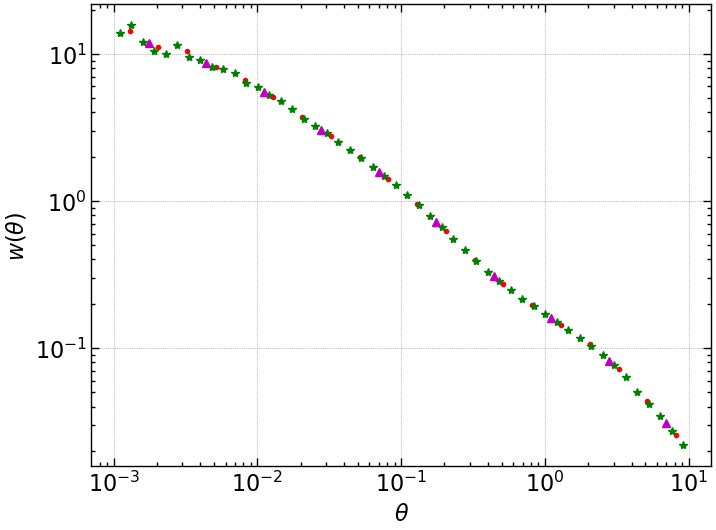

In [12]:
#plt.loglog(bins,w,'.')
# plt.loglog(theta1,w1,'*')
# plt.loglog(theta1,w2,'s')
#plt.plot(bins1,W_theta2,'k.')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$w(\theta)$')
plt.loglog(logbins20,W_theta_log_20_5times,'r.')
#plt.loglog(logbins50,W_theta_log_50_5times,'b-')
plt.loglog(logbins50,W_theta_log_50_5times,'g*')
plt.loglog(logbins10,W_theta_10_10times,'m^')
plt.grid(ls=':')
#plt.xscale('log')

In [13]:
import pyccl as ccl

cosmo = ccl.Cosmology(
    Omega_c=0.25,  # Cold dark matter density
    Omega_b=0.05,  # Baryon density
    h=0.67,        # Hubble parameter
    sigma8=0.8,    # Power spectrum normalization
    n_s=0.96       # Spectral index
)
import numpy as np

#z = np.linspace(0.01, 2.0, 100)
#n_z = np.exp(-((z-0.5)**2)/(2*0.1**2))  # example Gaussian n(z)


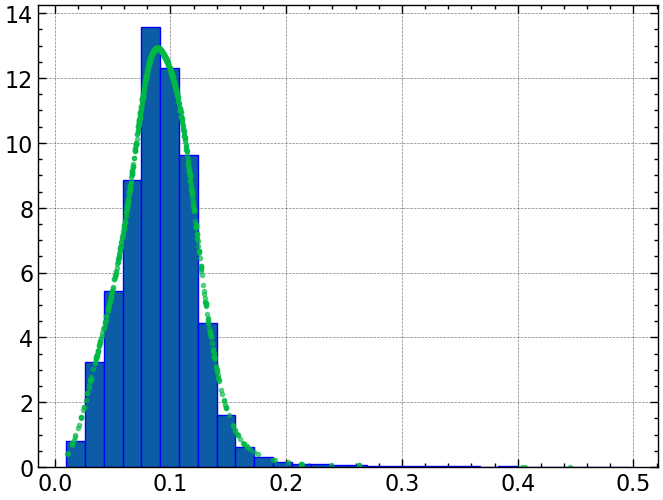

In [15]:
matched_dr=Table(fitsio.FITS('/user/animesh.sah/DESI_PECVEL/DR_matched.fits')[1].read())

from scipy.stats import gaussian_kde
kde = gaussian_kde(matched_dr['Z'],bw_method=0.25)
samples = kde.resample(700).flatten()
samples = np.clip(samples, 0, None)
y_samples=kde.evaluate(samples)
samples_sorted=np.sort(samples)
arg=np.argsort(samples)
y_samples_sorted= y_samples[arg]

plt.hist(matched_dr['Z'],bins=30,edgecolor='blue',label='DESI Spectral',density=True)

plt.plot(samples_sorted,y_samples_sorted,'.',alpha=0.6)
z=samples_sorted
n_z=y_samples_sorted
n_z /= np.trapz(y_samples_sorted, samples_sorted)


In [43]:
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
dL = cosmo.comoving_distance(samples_sorted).to(u.Mpc).value
num  = np.trapz(dL*n_z**2, z)
denom  = np.trapz(n_z**2, z)
chi_eff = num/denom
def theta_to_r(theta_deg):
    return chi_eff * np.deg2rad(theta_deg)

theta_to_r(10)

67.72211268281524

In [16]:
ccl.correlation

<function pyccl.correlations.correlation(cosmo, *, ell, C_ell, theta, type='NN', method='fftlog')>

In [24]:
np.log10(0.4)

-0.3979400086720376

In [25]:
gal_tracer = ccl.NumberCountsTracer(cosmo, has_rsd=False, dndz=(z, n_z), bias=(z, np.ones_like(z)))
ell = np.arange(2, 1000)
cl = ccl.angular_cl(cosmo, gal_tracer, gal_tracer, ell)
theta = np.logspace(-0.40, 1, 50)  # in radians (~0.06° to 57°)
wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)
wtheta

array([0.11334653, 0.10655825, 0.10018969, 0.09441942, 0.08897359,
       0.08398954, 0.07931171, 0.07502333, 0.07102002, 0.06734684,
       0.06386282, 0.0606744 , 0.05757638, 0.05469984, 0.05198649,
       0.04938869, 0.04691959, 0.04455634, 0.04228416, 0.04009881,
       0.0379977 , 0.03597051, 0.03400873, 0.03211304, 0.03028082,
       0.02850616, 0.02679077, 0.02513276, 0.02353075, 0.02198616,
       0.02049742, 0.01906612, 0.01769159, 0.0163747 , 0.01511575,
       0.01391473, 0.01277209, 0.01168788, 0.01066192, 0.00969398,
       0.00878362, 0.00793024, 0.00713301, 0.00639092, 0.00570279,
       0.00506723, 0.00448267, 0.00394745, 0.0034597 , 0.0030175 ])

In [26]:
np.sqrt(popt)

NameError: name 'popt' is not defined

In [ ]:
plt.loglog(theta,wtheta)
plt.loglog(theta,wfunc(popt,theta ))

In [ ]:

def wfunc(a,theta):
    wtheta = ccl.correlation( cosmo=cosmo,ell=ell, C_ell=cl, theta=theta)

    return a*wtheta

In [ ]:
x_input= np.array(logbins50)[np.array(logbins50)>0.4]
y_input = np.array(W_theta_log_50_5times)[logbins50>0.4]

In [ ]:
plt.loglog(x_input,y_input,'g.'   )
plt.loglog(logbins50,W_theta_log_50_5times,'r:')

In [ ]:
from scipy.optimize import curve_fit as cf
popt,pcov=cf(wfunc,x_input,y_input,p0=[1.5**2])
plt.loglog(x_input,wfunc(*popt,x_input))
plt.loglog(logbins50,W_theta_log_50_5times,'r.:')
#plt.loglog(x_input,y_input,'g*')

#plt.plot(l,wfunc(35,l))
#plt.xlim(0,300)
#plt.ylim(0,0.6)

In [ ]:
np.sqrt(popt)

In [ ]:
plt.loglog(theta,wtheta)
plt.loglog(logbins10,W_theta_50_10times,'m^')
#plt.loglog(logbins20,W_theta_log_20_5times,'r.')
#plt.loglog(x_input,wfunc(*popt,x_input))


In [ ]:
def ang_corr(theta,theta0,beta,ic):
    return (theta/theta0)**beta -ic

In [ ]:
from scipy.optimize import curve_fit as cf

cf(ang_corr, bins, w, p0=(4, -1.8,1))

In [ ]:
cf(ang_corr, theta1, w1, p0=(0.02076768, -0.27066076,  0.17821385),maxfev=900000)


In [ ]:
w1=[0.24606536, 0.12571287, 0.08833157, 0.06542823, 0.04849445, 0.04023184, 0.03334327, 0.02834132, 0.02385611, 0.02089147]
theta1=np.linspace(0.1,10,10)
w2=[0.24501175, 0.12547497, 0.08777424, 0.06517089, 0.04802887, 0.0398323,
 0.03307461, 0.02839961, 0.02406792, 0.02102814]

In [ ]:
w_true=[11.84197242, 8.74598415, 5.53000732, 3.03190092, 1.56438577, 0.71514033,
 0.30616937, 0.15877718, 0.08136707, 0.0306531]
x_true = np.logspace(-3, 1, nbins + 1) # note the +1 to nbins
x_true=(x_true[1:]+x_true[:-1])/2   


In [ ]:
import pyarrow.parquet as pq
import pandas as pd


tbl = pq.read_table("bootstrap_results.parquet")
list_of_arrays = tbl.column("bootstrap_test").to_pylist()   # returns list of lists/arrays
arr = np.vstack(list_of_arrays)  # shape (n_bootstrap, n_bins)
print(arr.shape)
arr[:,0]

len(arr)

In [ ]:
np.mean(arr,axis=0)

In [ ]:
plt.errorbar(x,mean,yerr=std,fmt='.',capsize=5)
plt.xscale('log')
plt.yscale('log')

In [ ]:
(bin_edges[:-1]+bin_edges[1:])/2

In [ ]:
from scipy.optimize import curve_fit as cf
def gaussian(x,mu,sigma):
    return (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x-mu)/sigma)**2)


In [ ]:
popt

In [ ]:
mu=[]
sigma=[]
for i in range(arr.shape[1]):
    plt.hist(arr[:,i],bins=30,edgecolor='k',alpha=0.5,density=True)
    hist, bin_edges = np.histogram(arr[:, i], bins=30,density=True)
    x=(bin_edges[:-1]+bin_edges[1:])/2
    #plt.plot(x,hist,'o')

    popt,pcov = cf(gaussian,x,hist,p0=[w_true[i],1])
    x_new=np.linspace(min(x),max(x),200)
    plt.plot(x_new,gaussian(x_new,*popt),'r--')
    plt.text(0.1,0.9,f'$\mu={popt[0]:.2f}$\n$\sigma={popt[1]:.2f}$',transform=plt.gca().transAxes)
    mu.append(popt[0])
    sigma.append(popt[1])
    plt.show()

    

In [ ]:
plt.errorbar(x_true,mu,yerr=sigma,fmt='.',capsize=4)
#plt.plot(x_true,w_true,'r--')
plt.xscale('log')
plt.yscale('log')

In [ ]:
plt.errorbar(x_true,mu,yerr=sigma,fmt='.',capsize=4)
#plt.plot(x_true,w_true,'r--')
plt.xscale('log')
#plt.yscale('log')

In [ ]:
for i in range(arr.shape[1]):
    data = arr[:, i]
    mu, std = norm.fit(data)
    plt.hist(data, bins=30, edgecolor='k', alpha=0.5, density=True, label='Histogram')
    xmin, xmax = plt.xlim()
    x
    p = norm.pdf(x, mu, std) = np.linspace(xmin, xmax, 100)for i in range(arr.shape[1]):
    data = arr[:, i]
    mu, std = norm.fit(data)
    plt.hist(data, bins=30, edgecolor='k', alpha=0.5, density=True, label='Histogram')
    xmin, xmax = plt.xlim()
    x
    p = norm.pdf(x, mu, std) = np.linspace(xmin, xmax, 100)for i in range(arr.shape[1]):
    data = arr[:, i]
    mu, std = norm.fit(data)
    plt.hist(data, bins=30, edgecolor='k', alpha=0.5, density=True, label='Histogram')
    xmin, xmax = plt.xlim()
    x
    plt.show()

In [ ]:
# # Bootstrap-t interval example for the population mean on a skewed distribution
# # (Exponential). We'll compare three intervals on one sample:
# # 1) Classic normal (Wald) CI
# # 2) Bootstrap percentile CI (for reference)
# # 3) Bootstrap-t CI (studentized bootstrap)

# import numpy as np
# import pandas as pd
# from scipy.stats import norm
# import matplotlib.pyplot as plt

# rng = np.random.default_rng(4402)

# # ----- 1) Generate a single dataset (skewed distribution) -----
# n = 30                                # smallish sample
# true_mean = 1.0                        # Exponential mean
# x = rng.exponential(scale=true_mean, size=n)

# # point estimate and standard error estimate
# xbar = x.mean()
# s = x.std(ddof=1)
# se_hat = s / np.sqrt(n)

# # ----- 2) Classic normal (Wald) CI -----
# alpha = 0.05
# z = norm.ppf(1 - alpha/2)
# wald_ci = (xbar - z*se_hat, xbar + z*se_hat)

# # ----- 3) Bootstrap: set up -----
# B = 10000
# boot_means = np.empty(B)
# boot_se = np.empty(B)
# t_star = np.empty(B)

# for b in range(B):
#     sample = rng.choice(x, size=n, replace=True)
#     m = sample.mean()
#     s_b = sample.std(ddof=1)
#     se_b = s_b / np.sqrt(n)
#     boot_means[b] = m
#     boot_se[b] = se_b
#     # studentized statistic
#     t_star[b] = (m - xbar) / se_b

# # Percentile CI (for reference)
# q_lo, q_hi = np.quantile(boot_means, [alpha/2, 1 - alpha/2])
# percentile_ci = (q_lo, q_hi)

# # ----- 4) Bootstrap-t CI -----
# t_lo, t_hi = np.quantile(t_star, [alpha/2, 1 - alpha/2])
# boot_t_ci = (xbar - t_hi * se_hat, xbar - t_lo * se_hat)

# # Collect results
# results = pd.DataFrame({
#     "Method": ["Wald (normal)", "Bootstrap Percentile", "Bootstrap-t (studentized)"],
#     "Lower": [wald_ci[0], percentile_ci[0], boot_t_ci[0]],
#     "Upper": [wald_ci[1], percentile_ci[1], boot_t_ci[1]]
# })
# results["Length"] = results["Upper"] - results["Lower"]


# # ----- 5) Visuals (optional): show the bootstrap t* distribution vs Normal -----
# plt.figure()
# # histogram of t*
# _ = plt.hist(t_star, bins=40, density=True)
# _ = plt.title("Bootstrap distribution of $t^* = (\\hat{\\theta}^* - \\hat{\\theta}) / \\hat{\\sigma}^*$")
# _ = plt.xlabel("t*")
# _ = plt.ylabel("Density")
# plt.show()

# # Also show the sample and intervals on a number line
# plt.figure()
# xmin = 0
# xmax = max(3, x.max())
# _ = plt.scatter(x, np.zeros_like(x), marker='|')  # rug plot
# _ = plt.axvline(true_mean, linestyle='--', label='True mean')
# # draw intervals
# y0 = 0.05
# dy = 0.05
# labels = ["Wald", "Percentile", "Bootstrap-t"]
# for i, (lo, hi) in enumerate([wald_ci, percentile_ci, boot_t_ci]):
#     y = y0 + i*dy
#     _ = plt.plot([lo, hi], [y, y], linewidth=3, label=labels[i])
# _ = plt.title("Intervals on the data axis")
# _ = plt.yticks([])
# _ = plt.xlabel("x")
# _ = plt.legend()
# plt.show()

# # Print the key numeric outputs as well
# print(f"Sample size n = {n}")
# print(f"x̄ = {xbar:.4f}, s = {s:.4f}, se_hat = {se_hat:.4f}")
# print("\nIntervals:")
# for m, (lo, hi) in zip(labels, [wald_ci, percentile_ci, boot_t_ci]):
#     print(f"{m:14s}: [{lo:.4f}, {hi:.4f}]  length={hi-lo:.4f}")


In [ ]:
x

In [ ]:
W = [14.82288229, 15.24468482, 12.88039696, 10.16329759, 10.65372248, 11.31194522,
    9.67892387, 9.21456251, 8.41365927, 7.8031726, 7.39266473, 6.44684015,
    5.97160717, 5.23792169, 4.79071106, 4.23931636, 3.65398495, 3.24509166,
    2.90436946, 2.54350105, 2.21055009, 1.96344695, 1.71523143, 1.48536849,Miniconda3-latest-Linux-x86_64.sh
    1.29347009, 1.10151218, 0.93378558, 0.79465338, 0.6638843, 0.55335519,
    0.46011043, 0.38975253, 0.32523481, 0.28187581, 0.24349298, 0.21105505,
    0.18979095, 0.16831305, 0.14803904, 0.13056149, 0.11454883, 0.10246603,
    0.0891144, 0.07727882, 0.06004826, 0.05156814, 0.03839172, 0.03609104,
    0.02558789, 0.02361335]
th = np.logspace(-3,1,50)

In [ ]:
plt.loglog(logbins50,W_theta_log_50_5times,'g*')
plt.loglog(th,W,'r.')

In [ ]:
plt.plot(100*(np.array(W)-W_theta_log_50_5times)/np.array(W),'.')

In [ ]:

th = np.logspace(-3,1,50)

In [ ]:
w_cf = [15.02222222, 14.99126001, 13.32360743, 10.47406601, 10.85489117, 11.29357179,
    9.73315364, 9.18450427, 8.468611, 7.73662726, 7.41005036, 6.41242854,
    5.96148378, 5.24278963, 4.77457945, 4.23745682, 3.6628722, 3.24594643,
    2.90841114, 2.54621205, 2.20411569, 1.96260146, 1.71425693, 1.48883376,
    1.29406646, 1.10365061, 0.93649495, 0.79657235, 0.66563376, 0.55486412,
    0.46126711, 0.3922224, 0.3255964, 0.28366608, 0.24523584, 0.21179782,
    0.19008126, 0.16856111, 0.14840784, 0.12990197, 0.11523495, 0.10223385,
    0.08951981, 0.0765246, 0.060778, 0.0514035, 0.03890863, 0.03653907,
    0.02508063, 0.02339452]

w_tc = [15.02222222, 14.99126001, 13.32360743, 10.47406601, 10.85242621, 11.28836425,
    9.73827392, 9.16875975, 8.47649873, 7.72494128, 7.45612343, 6.39354599,
    5.94244697, 5.23661722, 4.78683386, 4.23785723, 3.66560253, 3.2493411,
    2.90151612, 2.54150592, 2.20283989, 1.95487125, 1.70967698, 1.48742284,
    1.2817959, 1.10208866, 0.93402943, 0.79444712, 0.66547663, 0.55363977,
    0.46233927, 0.39238435, 0.32760541, 0.28513695, 0.24728739, 0.21514754,
    0.19238656, 0.17084412, 0.15064668, 0.13336789, 0.1175526, 0.1037761,
    0.09034715, 0.07699975, 0.06387539, 0.05065462, 0.04202901, 0.03460851,
    0.02781232, 0.0220203]



In [ ]:
plt.loglog(th,w_cf,'b.',label = 'Corrfunc')
plt.loglog(th,w_tc,'m.',label = 'TreeCorr')
plt.legend()
plt.xlabel(r'$\theta$')
plt.ylabel(r'$w(\theta)$')

In [ ]:
plt.plot(th,100*(np.array(w_tc)-w_cf)/np.array(w_cf),'m.')

In [ ]:
W = [1.48870742e+01, 1.46148526e+01, 1.53783462e+01, 1.37020677e+01,
    1.21972217e+01, 1.02198991e+01, 1.04621907e+01, 1.06702079e+01,
    1.25333139e+01, 9.60349838e+00, 9.59385823e+00, 9.61140774e+00,
    8.79859212e+00, 8.97459191e+00, 7.59155449e+00, 7.75209076e+00,
    7.41496323e+00, 6.86194242e+00, 6.71310818e+00, 6.11675080e+00,
    5.66099040e+00, 5.40650484e+00, 5.00372586e+00, 4.66604589e+00,
    4.32962746e+00, 3.97246867e+00, 3.64844005e+00, 3.36065634e+00,
    3.12860197e+00, 2.92216335e+00, 2.67324897e+00, 2.50015278e+00,
    2.27225419e+00, 2.09414901e+00, 1.93484544e+00, 1.80125124e+00,
    1.63588545e+00, 1.49202621e+00, 1.36430836e+00, 1.26011068e+00,
    1.13376698e+00, 1.03099554e+00, 9.24508623e-01, 8.33832589e-01,
    7.55241393e-01, 6.69788007e-01, 6.07718573e-01, 5.33061091e-01,
    4.80075418e-01, 4.31132897e-01, 3.88487144e-01, 3.46039353e-01,
    3.13531117e-01, 2.87320577e-01, 2.64420637e-01, 2.40356578e-01,
    2.19749765e-01, 2.05830285e-01, 1.91470168e-01, 1.78851966e-01,
    1.63876176e-01, 1.52356083e-01, 1.40484224e-01, 1.31068864e-01,
    1.20994374e-01, 1.12464480e-01, 1.03022226e-01, 9.40904415e-02,
    8.65336060e-02, 7.78870673e-02, 7.12011635e-02, 6.06746566e-02,
    5.29955372e-02, 4.59040086e-02, 4.13432438e-02, 3.71179022e-02,
    3.21709521e-02, 2.83680632e-02, 2.39732370e-02, 2.10517276e-02,
    1.75459090e-02, 1.41138389e-02, 1.14738255e-02, 9.02520245e-03,
    6.23183761e-03, 4.62503806e-03, 3.45732178e-03, 2.49542260e-03,
    -4.77257902e-04, -1.88915242e-03, 3.16514078e-04, 4.23873271e-04,
    6.89849784e-04, -6.93730638e-04, -2.21624396e-03, -3.81119800e-03,
    -4.90016116e-03, -1.34942862e-03, -1.07661326e-03, 5.26655226e-03]
nbins=100
bins = np.logspace(-3, 2, nbins ) # note the +1 to nbins



In [ ]:
plt.loglog(bins,W,'r.')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$w(\theta)$')

In [ ]:
np.mean(np.load('/user/animesh.sah/DESI_PECVEL/w_jk_array_jackknife_manual.npy'),axis=0)

In [ ]:
a[0]

In [ ]:
x_true,w_true,sigma

In [ ]:
a = np.load('logbins_treecorr.npy')
plt.errorbar(a[0], a[1],marker='.',ls='None',yerr=a[2],capsize=4)
#plt.loglog(bins,W,'k.')
plt.errorbar(x_true,w_true,yerr=sigma,fmt='.',capsize=4)
plt.yscale('log')  
plt.xscale('log')
plt.xlabel(r'$\theta$')
plt.ylabel(r'$w(\theta)$')
plt.legend(['Corrfunc with bootstrap','Treecorr with inbuilt jackknife'])

In [ ]:
bootstrap[0][0]

In [ ]:
bootstrap

In [ ]:
sigma

In [ ]:
w_true

In [ ]:
np.shape(lst_boot)

In [ ]:
x= np.logspace(-3,1,20)

In [ ]:
lst_boot

In [ ]:
import pyarrow.parquet as pq
bootstrap = pq.read_table("/user/animesh.sah/DESI_PECVEL/bootstrap_results_oneby10.parquet")
k = bootstrap.column("bootstrap_test").to_pylist()   # returns list of lists/arrays
lst_boot = np.vstack(k)
lst_boot
mean=[]
std=[]
for i in range(20):
    plt.hist(lst_boot[:,i],bins=30,edgecolor='k',alpha=0.5)
    #plt.axvline(W[i],color='r',ls='-.')
    mean.append(lst_boot[:,i].mean())
    std.append(lst_boot[:,i].std())
    plt.show()

In [ ]:
plt.loglog(x,mean,'.')


In [ ]:
len(x)

In [ ]:
from sklearn.cluster import KMeans


In [ ]:
random_compiled = fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_1M.fits')[1].read()
rand_table=Table(random_compiled)
sample_size =5*480896

rand_table = rand_table[rand_table['DEC'] > -30]
idx = np.random.choice(len(rand_table), sample_size, replace=False)

rand_table = rand_table[idx]

table_selection = Table(fitsio.FITS('table_match_final.fits')[1].read())
table_selection = table_selection
#rng = np.random.default_rng(34023)

#idx = rng.choice(len(table_selection), len(table_selection), replace=True)
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
RA_random,DEC_random = rand_table['RA'], rand_table['DEC']  
RA_data   = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
DEC_data  = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))
RA_random = np.ascontiguousarray(np.array(RA_random, dtype=np.float64))
DEC_random= np.ascontiguousarray(np.array(DEC_random, dtype=np.float64))

In [ ]:
ra_rad = np.deg2rad(RA_random)
dec_rad = np.deg2rad(DEC_random)

In [ ]:
x = np.cos(ra_rad) * np.cos(dec_rad)
y = np.sin(ra_rad) * np.cos(dec_rad)
z = np.sin(dec_rad)
rand_coords = np.vstack([x, y, z]).T
N_jk = 100

In [ ]:
kmeans = KMeans(n_clusters=N_jk).fit(coords)
labels_random = kmeans.labels_
centers = kmeans.cluster_centers_

In [ ]:
labels_random = kmeans.predict(rand_coords)

In [ ]:
ra_rad_data = np.deg2rad(RA_data)
dec_rad_data = np.deg2rad(DEC_data)
x_data = np.cos(ra_rad_data) * np.cos(dec_rad_data)
y_data = np.sin(ra_rad_data) * np.cos(dec_rad_data)
z_data = np.sin(dec_rad_data)
data_coords = np.vstack([x_data, y_data, z_data]).T
data_coords

In [ ]:
# kmeans = KMeans(n_clusters=N_jk, random_state=41, n_init=20)
# labels_randoms = kmeans.fit_predict(coords)

In [ ]:
labels_data = kmeans.predict(data_coords)

In [ ]:
def cartesian_to_radec(x, y, z, degrees=True):

    # Normalize vector just in case
    r = np.sqrt(x**2 + y**2 + z**2)
    x, y, z = x/r, y/r, z/r

    dec = np.arcsin(z)                  # [-pi/2, pi/2]
    ra = np.arctan2(y, x)                # [-pi, pi]
    ra = np.mod(ra, 2*np.pi)             # [0, 2pi)

    if degrees:
        ra = np.degrees(ra)
        dec = np.degrees(dec)

    return ra, dec

In [ ]:
np.loasd

In [ ]:
import matplotlib.cm as cm

lengths = []
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

unique_labels_data = np.unique(labels_data)
unique_labels_random = np.unique(labels_random)

colors = cm.get_cmap('tab20', len(unique_labels_data))
nside = 1024
for idx, i in enumerate(unique_labels_data):
    mask = labels_data == i
    #ra,dec= data_coords[mask][:,0],data_coords[mask][:,1]
    # ra_array = np.ascontiguousarray(np.array(ra, dtype=np.float64))
    # dec_array = np.ascontiguousarray(np.array(dec, dtype=np.float64))
    # theta = np.radians(90.0 - dec_array)  # theta = 0 at North Pole
    # phi = np.radians(ra_array) 
    # pix_indices = hp.ang2pix(nside, theta, phi,nest=False)
    # npix = hp.nside2npix(nside)
    # counts = np.bincount(pix_indices, minlength=npix)
    # mask_hpx = counts[pix_indices] > 0


    # theta_data = np.radians(90.0 - DEC_data)  # theta = 0 at North Pole
    # phi_data = np.radians(RA_data)
    # pix_indices_data = hp.ang2pix(nside, theta_data, phi_data,nest=False)
    # data_jackknife = 
    
    radec_coords_data = np.array(list(map(lambda xyz: cartesian_to_radec(*xyz), data_coords[mask])))
    ra_data_vals, dec_data_vals = radec_coords_data[:, 0], radec_coords_data[:, 1]

    #cluster_data = data_coords[labels_data == cluster_id]

    ra_data, dec_data = prepare_coords(ra_data_vals, dec_data_vals)
    ax.plot(ra_data, dec_data, ',', alpha=0.7, color=colors(idx))
    lengths.append(len(ra_data))



    #ra_data,dec_data

plt.show()
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')


for idx, i in enumerate(unique_labels_random):
    mask = labels_random == i
    #ra,dec= data_coords[mask][:,0],data_coords[mask][:,1]
    # ra_array = np.ascontiguousarray(np.array(ra, dtype=np.float64))
    # dec_array = np.ascontiguousarray(np.array(dec, dtype=np.float64))
    # theta = np.radians(90.0 - dec_array)  # theta = 0 at North Pole
    # phi = np.radians(ra_array) 
    # pix_indices = hp.ang2pix(nside, theta, phi,nest=False)
    # npix = hp.nside2npix(nside)
    # counts = np.bincount(pix_indices, minlength=npix)
    # mask_hpx = counts[pix_indices] > 0


    # theta_data = np.radians(90.0 - DEC_data)  # theta = 0 at North Pole
    # phi_data = np.radians(RA_data)
    # pix_indices_data = hp.ang2pix(nside, theta_data, phi_data,nest=False)
    # data_jackknife = 
    
    radec_coords_rand = np.array(list(map(lambda xyz: cartesian_to_radec(*xyz), rand_coords[mask])))
    ra_random_vals, dec_random_vals = radec_coords_rand[:, 0], radec_coords_rand[:, 1]

    #cluster_data = data_coords[labels_data == cluster_id]

    ra_random, dec_random = prepare_coords(ra_random_vals, dec_random_vals)
    ax.plot(ra_random, dec_random, ',', alpha=0.7, color=colors(idx))
    lengths.append(len(ra_random))



    #ra_data,dec_data
    


In [ ]:
def define_patch(N_jk):
    ra_rad = np.deg2rad(RA_random)
    dec_rad = np.deg2rad(DEC_random)
    x = np.cos(ra_rad) * np.cos(dec_rad)
    y = np.sin(ra_rad) * np.cos(dec_rad)
    z = np.sin(dec_rad)
    coords = np.vstack([x, y, z]).T
    kmeans = KMeans(n_clusters=N_jk, random_state=42).fit(coords)
    labels_random = kmeans.labels_
    centers = kmeans.cluster_centers_
    return kmeans

def patchify(ra,dec,index,N_jk=10):
    ra_rad = np.deg2rad(ra)
    dec_rad = np.deg2rad(dec)
    x = np.cos(ra_rad) * np.cos(dec_rad)
    y = np.sin(ra_rad) * np.cos(dec_rad)
    z = np.sin(dec_rad)
    kmeans = define_patch(N_jk)
    coords = np.vstack([x,y,z]).T
    labels = kmeans.predict(coords)

    mask = labels != index
    radec_coords = np.array(list(map(lambda xyz: cartesian_to_radec(*xyz), coords[mask])))
    ra_vals, dec_vals = radec_coords[:, 0], radec_coords[:, 1]
    
    return ra_vals, dec_vals





In [ ]:
DEC_random

In [ ]:
a=patchify(RA_data,DEC_data,1)
b=patchify(RA_random,DEC_random,1)
ra,dec=prepare_coords(a[0],a[1])
ra1,dec1=prepare_coords(b[0],b[1])

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

ax.plot(ra, dec, '.', alpha=0.7)


ax.plot(ra1, dec1, ',', alpha=0.05)

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

ax.plot(ra, dec, ',', alpha=0.7)

In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

ax.plot(ra, dec, ',', alpha=0.7)


In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

ax.plot(ra, dec, ',', alpha=0.7)


In [ ]:
fig = plt.figure(figsize=(10, 5))
ax = fig.add_subplot(111, projection='mollweide')

ax.plot(ra, dec, ',', alpha=0.7)


In [ ]:
plt.hist(lengths)

In [ ]:
coords[labels_randoms]


radec_coords = np.array(list(map(lambda xyz: cartesian_to_radec(*xyz), coords[labels_randoms])))
ra_vals, dec_vals = radec_coords[:,0], radec_coords[:,1]
plt.figure(figsize=(8,4))
plt.scatter(ra_vals, dec_vals, s=1, alpha=0.5)
plt.xlabel('RA (deg)')
plt.ylabel('Dec (deg)')
plt.title('RA/Dec of clustered randoms')
plt.grid(True, ls=':')
plt.show()

In [ ]:
plt.hist(labels_randoms)


In [ ]:
import treecorr
import numpy as np
import fitsio
from astropy.table import Table
import Corrfunc
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.io import read_catalog
from Corrfunc.utils import convert_3d_counts_to_cf
random_compiled = fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_1M.fits')[1].read()
rand_table=Table(random_compiled)
sample_size =5*480896

rand_table = rand_table[rand_table['DEC'] > -30]
idx = np.random.choice(len(rand_table), sample_size, replace=False)

rand_table = rand_table[idx]

table_selection = Table(fitsio.FITS('table_match_final.fits')[1].read())
table_selection = table_selection
#rng = np.random.default_rng(34023)

#idx = rng.choice(len(table_selection), len(table_selection), replace=True)
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']
RA_random,DEC_random = rand_table['RA'], rand_table['DEC']  

npatch=100
cat_data = treecorr.Catalog(ra=RA_data, dec=DEC_data, ra_units='deg', dec_units='deg', npatch=npatch)
cat_rand = treecorr.Catalog(ra=RA_random, dec=DEC_random, ra_units='deg', dec_units='deg',patch_centers=cat_data.patch_centers)

nbins = 100
min_sep = 0.001  # degrees, example
max_sep = 100   # degrees

print('theta:',np.logspace(np.log10(min_sep),np.log10(max_sep),nbins))
dd = treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg'  ,  bin_type='Log'  , var_method='jackknife')# bins are spaced evenly in log10(sep)
dr =  treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg' ,  bin_type='Log'  ) 
rr =  treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg' ,  bin_type='Log'  ) 

dd.process(cat_data)
dr.process(cat_data, cat_rand)
rr.process(cat_rand)

# Now .xi is populated


xi, varxi = dd.calculateXi(rr=rr, dr=dr)
sig = np.sqrt(varxi)

In [ ]:
cov = treecorr.estimate_multi_cov([dd], 'jackknife')

Mean counts per pixel 2090.8521739130433


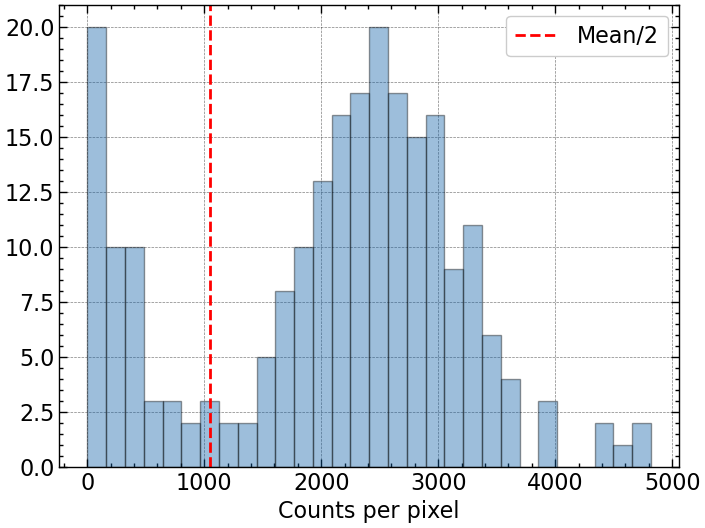

In [16]:
nside=6
counts=hist_pix(RA_data,DEC_data,nside=nside)
counts = counts[counts>0]
mean = np.mean(counts)
threshold = mean/2
print('Mean counts per pixel',np.mean(counts))
plt.hist(counts,bins=30,edgecolor='k',alpha=0.4)
plt.axvline(threshold ,color='r', ls='--', label='Mean/2')
plt.xlabel('Counts per pixel')
plt.legend()

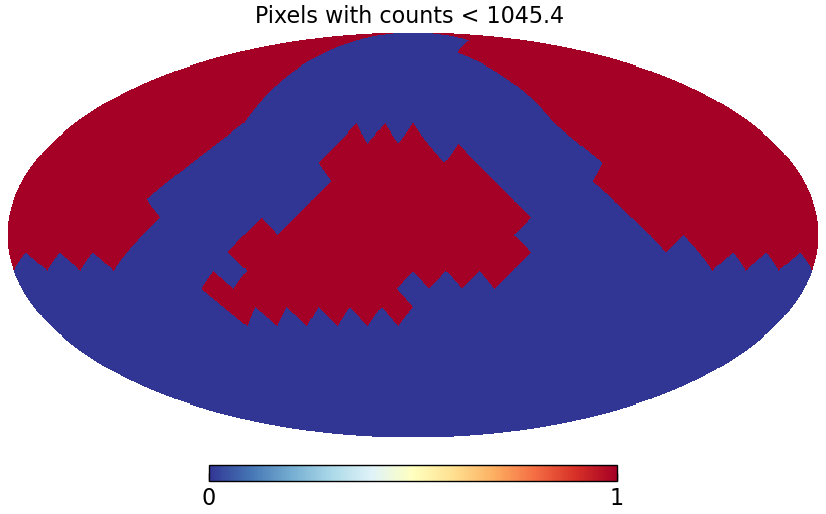

Number of pixels with counts < threshold: 180
Total number of pixels: 432


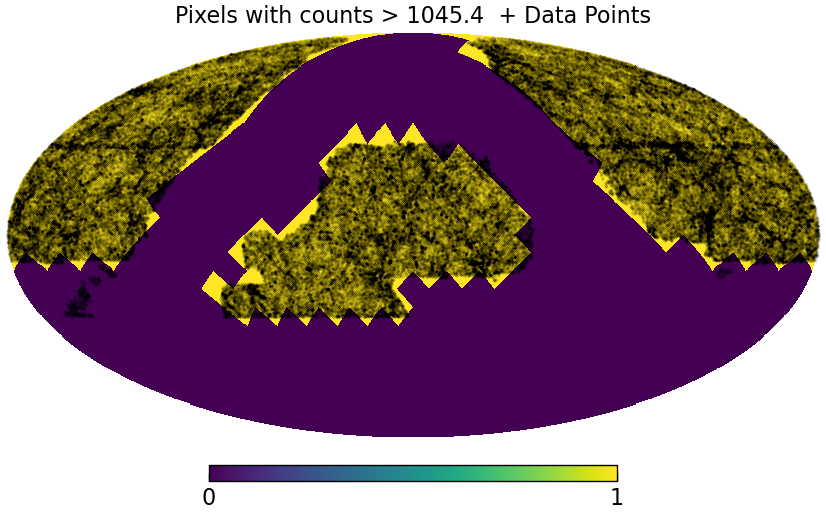

In [27]:
# Create mask for pixels with counts < mean/2

counts_full = hist_pix(RA_data, DEC_data, nside=nside)
#counts_full = counts_full[counts_full > 0]
mask = counts_full >threshold

# Create a map where masked pixels are 1, others are 0
plot_map = mask.astype(float)

# Plot using healpy mollview
hp.mollview(plot_map, title=f'Pixels with counts < {threshold:.1f} ', 
            cmap='RdYlBu_r', cbar=True)
plt.show()
# Overlay data points on the map
ra_data_rad = np.deg2rad(RA_data)
dec_data_rad = np.deg2rad(DEC_data)

# Convert to theta, phi for healpy (theta = colatitude)
theta_data = np.pi/2 - dec_data_rad
phi_data = ra_data_rad

# Create the plot with data points overlaid
hp.mollview(plot_map, title=f'Pixels with counts > {threshold:.1f}  + Data Points', 
            cmap='viridis', cbar=True)
# for ipix in range(hp.nside2npix(nside)):
#     # get the boundary of the pixel in theta, phi
#     xyz = hp.boundaries(nside, ipix, step=1)  # shape (3, N)
#     x, y, z = xyz
    
#     # Convert to spherical coords
#     theta = np.arccos(z)        # polar angle
#     phi = np.arctan2(y, x)  
#     lon = np.degrees(phi) - 180  # convert to Mollweide coords
#     lat = np.degrees(0.5*np.pi - theta)
#     plt.plot(lon, lat, color="k", linewidth=0.2)  # black borders
hp.projscatter(theta_data, phi_data, s=0.1, c='black', alpha=0.2, marker='.')
print(f'Number of pixels with counts < threshold: {np.sum(mask)}')
print(f'Total number of pixels: {len(counts_full)}')

In [25]:
hp.boundaries(nside, ipix, step=1)

array([[0.00000000e+00, 1.35767392e-01, 1.90659817e-01, 3.84597719e-17],
       [0.00000000e+00, 0.00000000e+00, 1.90659817e-01, 1.35767392e-01],
       [1.00000000e+00, 9.90740741e-01, 9.62962963e-01, 9.90740741e-01]])

In [17]:
plot_map

array([1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.,
       0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 1., 1., 1., 1., 1., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 0., 0., 1.,
       1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
       1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0.,
       0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       1., 1., 1., 1., 0.

In [ ]:
npix = np.arange(hp.nside2npix(nside))#npix
npix

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [ ]:
kj

Total number of usable pixles are: 180


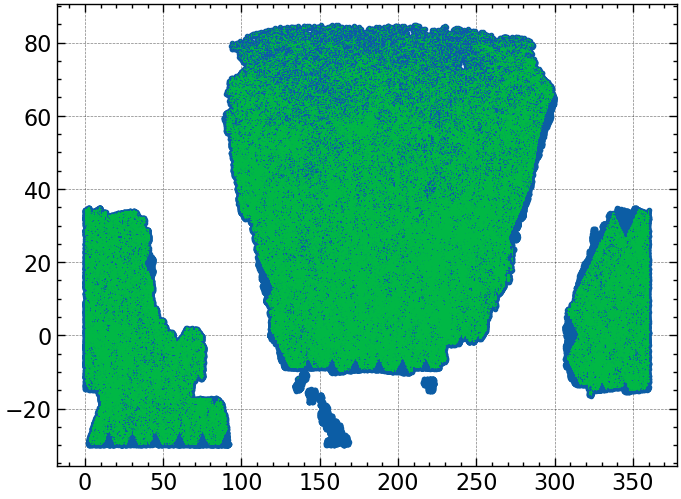

In [6]:
nside=6
counts=hist_pix(RA_data,DEC_data,nside=nside)
counts_full = np.copy(counts)
counts = counts[counts>0]
mean = np.mean(counts)
threshold = mean/2
#counts_full = hist_pix(RA_data, DEC_data, nside=nside)
mask = counts_full < threshold
plot_map = mask.astype(float)   
npix = pixelize(RA_data, DEC_data, nside=nside) ##pixels corresponding to RA AND DEC
pixels = np.arange(0,12*nside**2)
jk_indexes = pixels[~plot_map.astype(bool)]    ## pixels which can be used for jackknife
indexes = np.where(np.isin(npix,jk_indexes))[0] ##indexes of the RA AND DEC which can be used for jackknife
print('Total number of usable pixles are:',len(counts_full[~mask.astype(bool)]))
plt.plot(RA_data,DEC_data,'.' )
plt.plot(RA_data[indexes],DEC_data[indexes],',',alpha=0.8)
plt.show()

In [66]:
def prepare_jackknife(RA,DEC,nside=6):
    # takes in RA and DEC and returns the pixel indices and the usable indexes for jackknife
    counts=hist_pix(RA,DEC,nside=nside)
    counts_full = np.copy(counts)
    counts = counts[counts>0]
    mean = np.mean(counts)
    threshold = mean/2
    #counts_full = hist_pix(RA_data, DEC_data, nside=nside)
    mask = counts_full < threshold
    plot_map = mask.astype(float)   
    npix = pixelize(RA, DEC, nside=nside) ##pixels corresponding to RA AND DEC
    pixels = np.arange(0,12*nside**2)
    jk_indexes = pixels[~plot_map.astype(bool)]    ## pixels which can be used for jackknife
    indexes = np.where(np.isin(npix,jk_indexes))[0] ##indexes of the RA AND DEC which can be used for jackknife
    print('Total number of usable pixles are:',len(counts_full[~mask.astype(bool)]))
    return npix,jk_indexes, indexes

In [29]:
import multiprocessing

In [67]:
[(RA_data, DEC_data, index, nside) for index in jk_indexes]

[(array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]),
  1,
  6),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]),
  2,
  6),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]),
  6,
  6),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]),
  7,
  6),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),

In [47]:
len([(RA_data, DEC_data, index, nside) for index in jk_indexes])

2

In [75]:
ra,dec=leave_one_out_data(RA_data, DEC_data, jk_indexes[i], nside=nside)
ra,dec

Total number of usable pixles are: 180


(array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
        351.49250651, 351.49455459]),
 array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
        34.04852205, 33.87586033]))

Total number of usable pixles are: 180


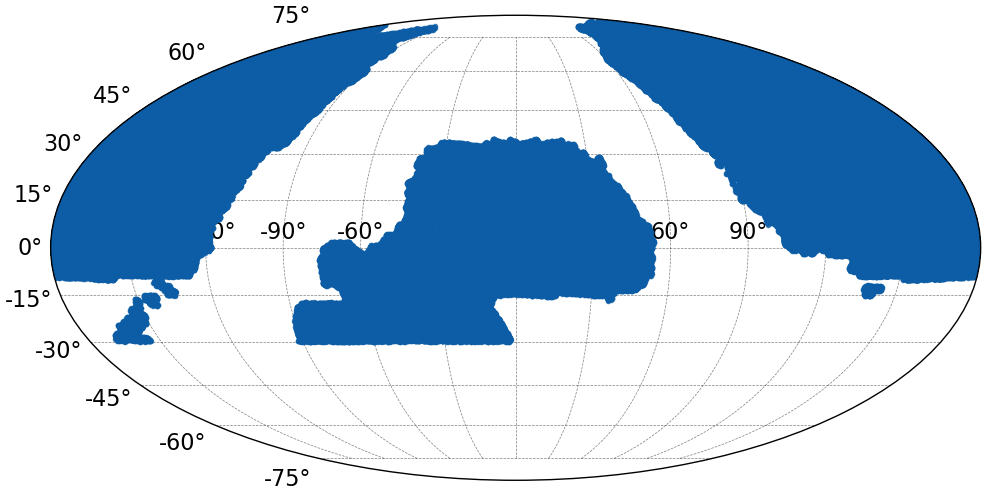

Total number of usable pixles are: 180


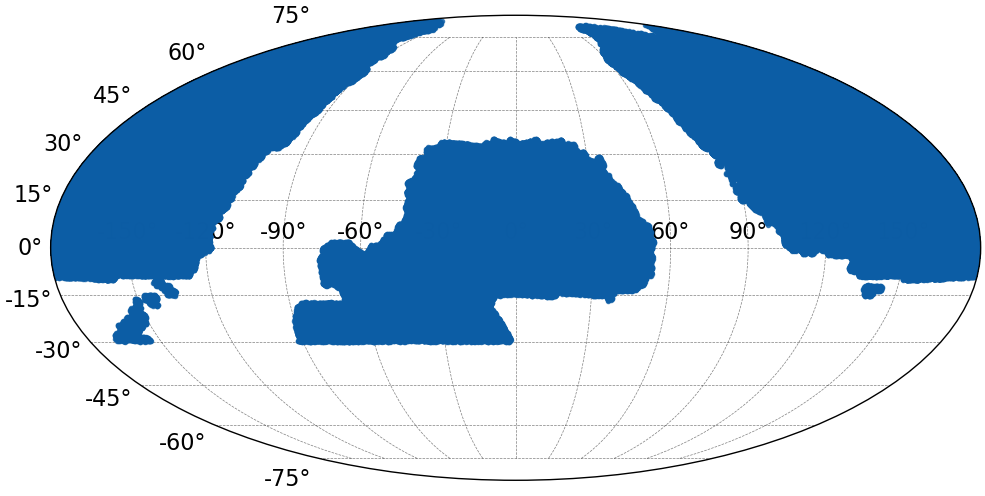

Total number of usable pixles are: 180


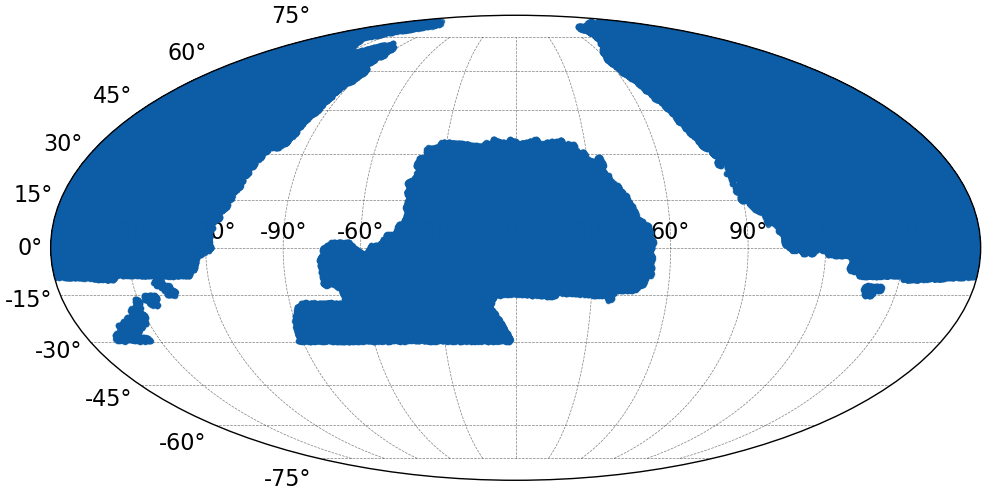

Total number of usable pixles are: 180


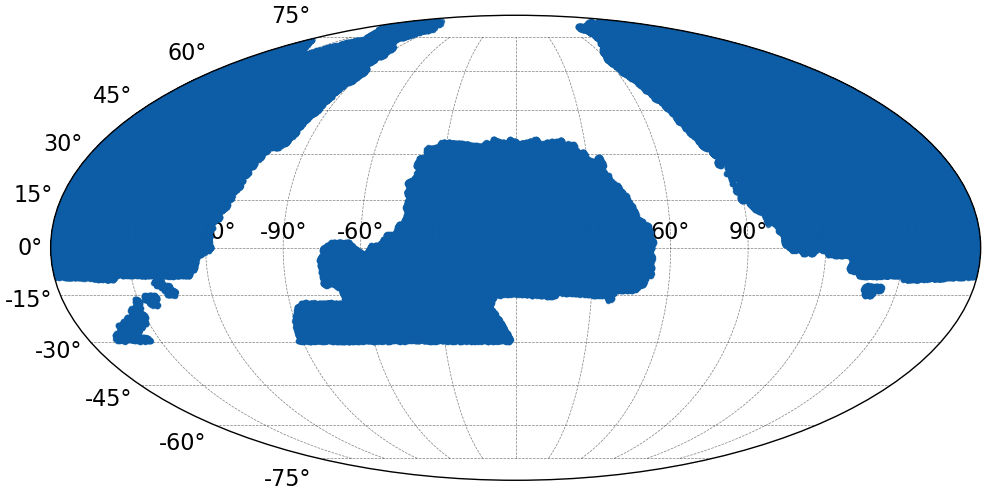

Total number of usable pixles are: 180


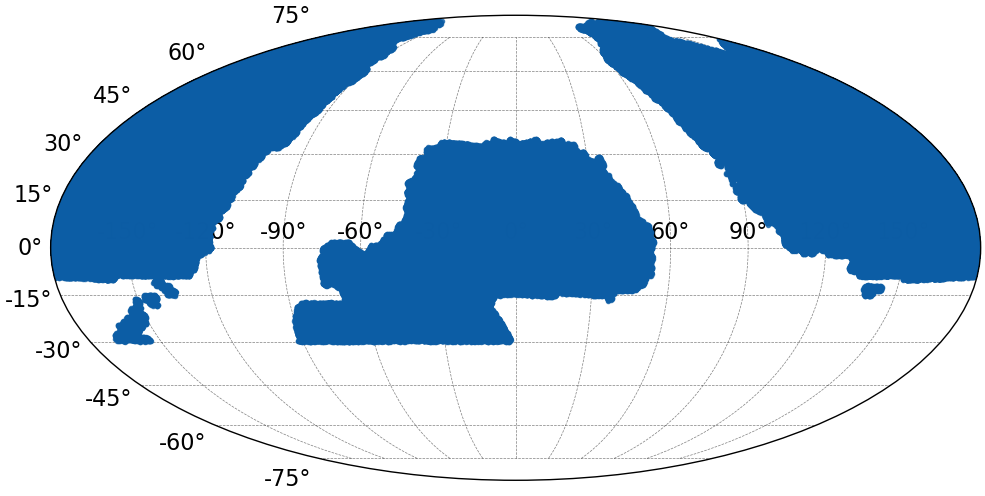

Total number of usable pixles are: 180


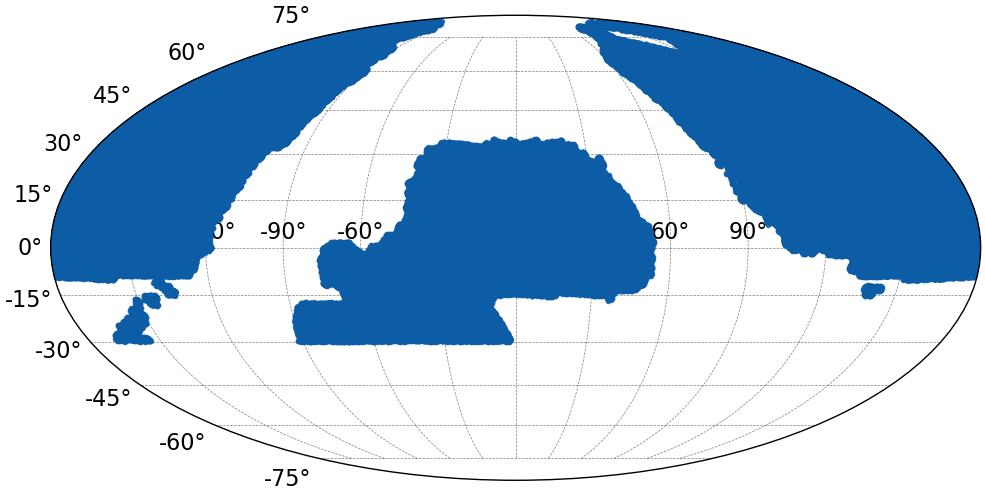

Total number of usable pixles are: 180


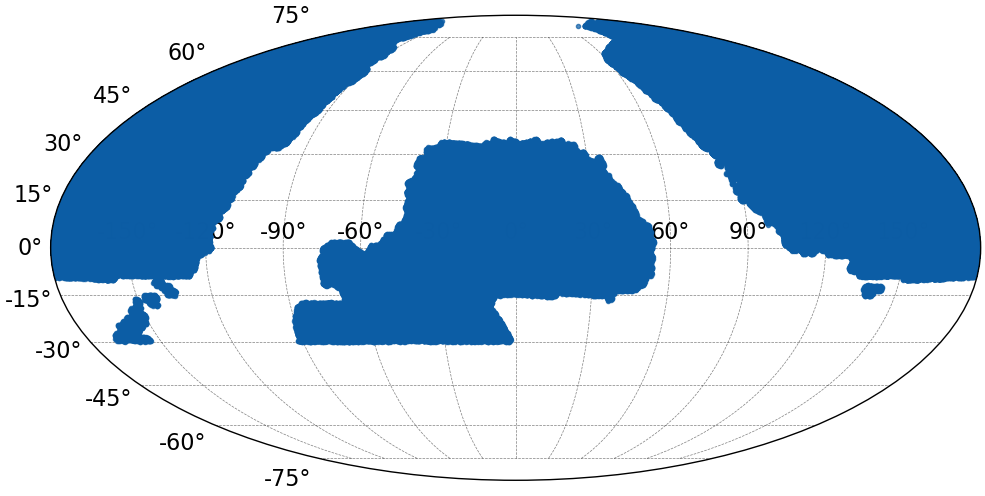

Total number of usable pixles are: 180


KeyboardInterrupt: 

In [72]:
for i in range(len(jk_indexes)):
    ra,dec=leave_one_out_data(RA_data, DEC_data, jk_indexes[i], nside=nside)
    ra,dec=prepare_coords(ra,dec)
    fig = plt.figure(figsize=(12, 7))
    ax = fig.add_subplot(111, projection='mollweide')
    ax.plot(rooa, dec, '.', alpha=0.7)
    plt.show()
# ra,dec=leave_one_out_data(RA_data, DEC_data, 100, nside=6)
# ra,dec=prepare_coords(ra,dec)
# fig = plt.figure(figsize=(12, 7))
# ax = fig.add_subplot(111, projection='mollweide')
# ax.plot(ra, dec, '.', alpha=0.7)

In [98]:
def leave_one_out_data(RA,DEC,index,nside=6):
    # takes in RA and DEC and the index of the pixel to be removed
    # returns the RA and DEC after removing the pixel
    npix,jk_indexes,indexes = prepare_jackknife(RA,DEC,nside=nside)
    mask = npix != index
    return RA[mask], DEC[mask]
def leave_one_out_random(RA,DEC,index,nside=6):
    # takes in RA and DEC and the index of the pixel to be removed
    # returns the RA and DEC after removing the pixel
    npix_random = pixelize(RA, DEC, nside=nside) ##pixels corresponding to RA AND DEC
    mask = npix_random != index
    return RA[mask], DEC[mask]

_,jk_indexes,_= prepare_jackknife(RA_data,DEC_data,nside=nside)
jk_indexes = [300,214,76]

with multiprocessing.Pool(processes=2) as pool:
    data_jk = pool.starmap(leave_one_out_data, [(RA_data, DEC_data, index, nside) for index in jk_indexes])
    random_jk= pool.starmap(leave_one_out_random, [(RA_random, DEC_random, index, nside) for index in jk_indexes])
    w_jk=pool.starmap(w_theta_corrfunc, [(data_jk[i][0], data_jk[i][1], random_jk[i][0], random_jk[i][1]) for i in range(len(jk_indexes))])
    #w = w

    

Total number of usable pixles are: 180


Total number of usable pixles are: 180
Total number of usable pixles are: 180
Total number of usable pixles are: 180
[ 37.17307615  37.17605431  37.17765762 ... 351.44478993 351.49250651
 351.49455459]
Shape of ra data (478568,)
8.729282080034812
[ 37.17307615  37.17605431  37.17765762 ... 351.44478993 351.49250651
 351.49455459]
Shape of ra data (477424,)
8.713737886826557
[ 37.17307615  37.17605431  37.17765762 ... 351.44478993 351.49250651
 351.49455459]
Shape of ra data (478422,)
8.714530787126144


Process ForkPoolWorker-117:
Process ForkPoolWorker-118:
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/usr/lib/python3.10/multiprocessing/queues.py", line 364, in get
    with self._rlock:
  File "/usr/lib/python3.10/multiprocessing/synchronize.py", line 95, in __enter__
    return self._semlock.__enter__()
KeyboardInterrupt
Traceback (most recent call last):
  File "/usr/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/usr/lib/python3.10

KeyboardInterrupt: 

In [97]:
[(data_jk[i][0], data_jk[i][1], random_jk[i][0], random_jk[i][1]) for i in range(len(jk_indexes))]

[(array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]),
  array([118.12595062, 156.66768285, 167.48642756, ..., 134.46307777,
         123.39859936, 339.78118228]),
  array([ 27.63590231,  33.96949344,  -6.08404022, ...,  10.35255966,
          56.69260902, -12.59699823])),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]),
  array([118.12595062, 156.66768285, 167.48642756, ..., 134.46307777,
         123.39859936, 339.78118228]),
  array([ 27.63590231,  33.96949344,  -6.08404022, ...,  10.35255966,
          56.69260902, -12.59699823])),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.8465

In [95]:
w_theta_corrfunc(ra_data_jk,dec_data_jk,ra_random_jk,dec_random_jk)

[ 37.17307615  37.17605431  37.17765762 ... 351.44478993 351.49250651
 351.49455459]
Shape of ra data (478568,)
8.729282080034812


(array([1.29244660e-03, 2.04838981e-03, 3.24647907e-03, 5.14532258e-03,
        8.15478672e-03, 1.29244660e-02, 2.04838981e-02, 3.24647907e-02,
        5.14532258e-02, 8.15478672e-02, 1.29244660e-01, 2.04838981e-01,
        3.24647907e-01, 5.14532258e-01, 8.15478672e-01, 1.29244660e+00,
        2.04838981e+00, 3.24647907e+00, 5.14532258e+00, 8.15478672e+00]),
 array([14.42212539, 10.83628818, 10.29686067,  8.24567014,  6.73633729,
         5.14007677,  3.7751664 ,  2.77897816,  1.99862098,  1.41596266,
         0.96008124,  0.62729095,  0.40242987,  0.27236989,  0.19657415,
         0.14552198,  0.10661514,  0.07285846,  0.04403445,  0.02626532]))

In [93]:
np.logspace(np.log10(0.001), np.log10(100), nbins+1 )


array([1.00000000e-03, 3.16227766e-03, 1.00000000e-02, 3.16227766e-02,
       1.00000000e-01, 3.16227766e-01, 1.00000000e+00, 3.16227766e+00,
       1.00000000e+01, 3.16227766e+01, 1.00000000e+02])

In [ ]:
def w_theta_corrfunc(ra_data,dec_data,ra_random,dec_random,min_sep=0.001,max_sep=10,nbins=20,nthreads=120):
    #print(ra_data)
    #print("Shape of ra data",ra_data.shape)
    bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins+1 )
    autocorr=1
    N=len(ra)
    N_rand = len(ra_random)
    print(N_rand/N)
    #print('Starting code')
    #print('Length of data is',N)
    DD_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_data, dec_data)
    autocorr=0
    #print('Done with DD counts')
    DR_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_data, dec_data,RA2=ra_random, DEC2=dec_random)
    autocorr=1
    RR_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_random,dec_random)
    wtheta = convert_3d_counts_to_cf(N, N, rand_N, rand_N, DD_counts, DR_counts,DR_counts, RR_counts)
    #print('W_theta',wtheta)
    return (bins[1:]+bins[:-1])/2,wtheta

In [ ]:
data_jk

[(array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033])),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033])),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]))]

In [80]:
[(ra,dec) for ra,dec in data_jk]

[(array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033])),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033])),
 (array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]))]

In [78]:
random_jk

[(array([118.12595062, 156.66768285, 167.48642756, ..., 134.46307777,
         123.39859936, 339.78118228]),
  array([ 27.63590231,  33.96949344,  -6.08404022, ...,  10.35255966,
          56.69260902, -12.59699823])),
 (array([118.12595062, 156.66768285, 167.48642756, ..., 134.46307777,
         123.39859936, 339.78118228]),
  array([ 27.63590231,  33.96949344,  -6.08404022, ...,  10.35255966,
          56.69260902, -12.59699823])),
 (array([118.12595062, 156.66768285, 167.48642756, ..., 134.46307777,
         123.39859936, 339.78118228]),
  array([ 27.63590231,  33.96949344,  -6.08404022, ...,  10.35255966,
          56.69260902, -12.59699823]))]

In [64]:
[(RA_data, DEC_data, index, nside) for index in jk_indexes]

[(array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
         351.49250651, 351.49455459]),
  array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
         34.04852205, 33.87586033]),
  300,
  6)]

In [35]:
ra,dec

(array([ 37.17307615,  37.17605431,  37.17765762, ..., 351.44478993,
        351.49250651, 351.49455459]),
 array([-0.83594182, -0.84650785, -0.84927412, ..., 33.87642528,
        34.04852205, 33.87586033]))

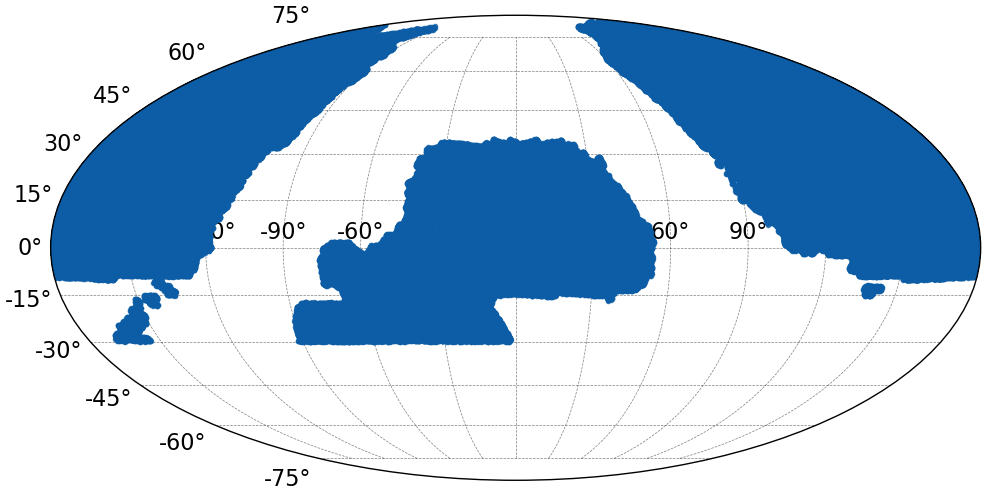

In [61]:
ra,dec=prepare_coords(data_jk[0][0],data_jk[0][1])
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')
ax.plot(ra, dec, '.', alpha=0.7)


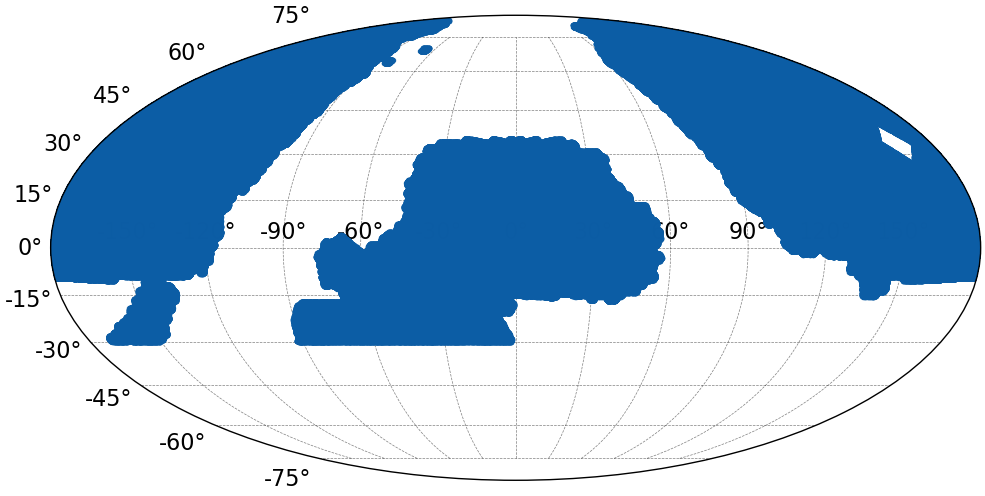

In [ ]:
ra,dec=prepare_coords(random_jk[0][0],random_jk[0][1])
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')
ax.plot(ra, dec, '.', alpha=0.7)


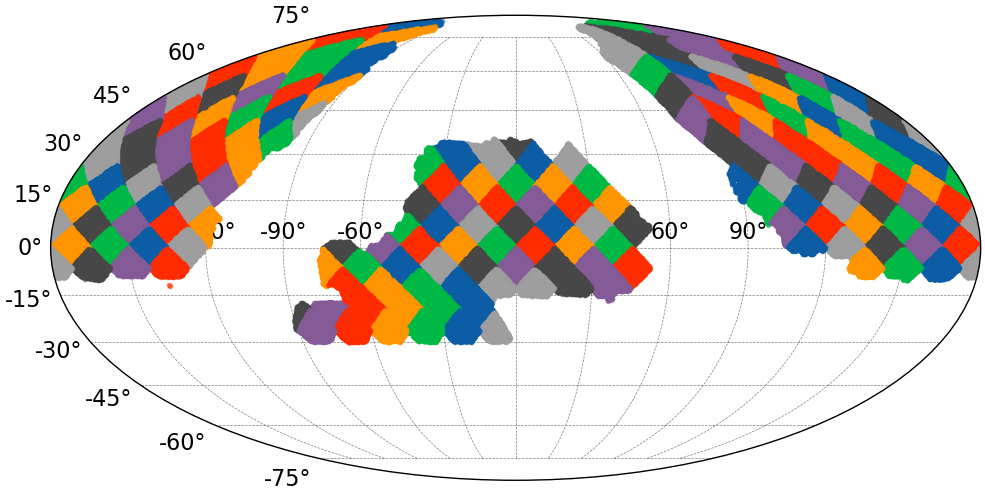

In [ ]:
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')
for i in jk_indexes:
    ra,dec=RA_data[np.where(npix==i)],DEC_data[np.where(npix==i)]
    ra,dec=prepare_coords(ra,dec)
    ax.plot(ra,dec,'.',alpha=0.5)

In [ ]:
npix

array([206, 206, 206, ..., 107, 107, 107])

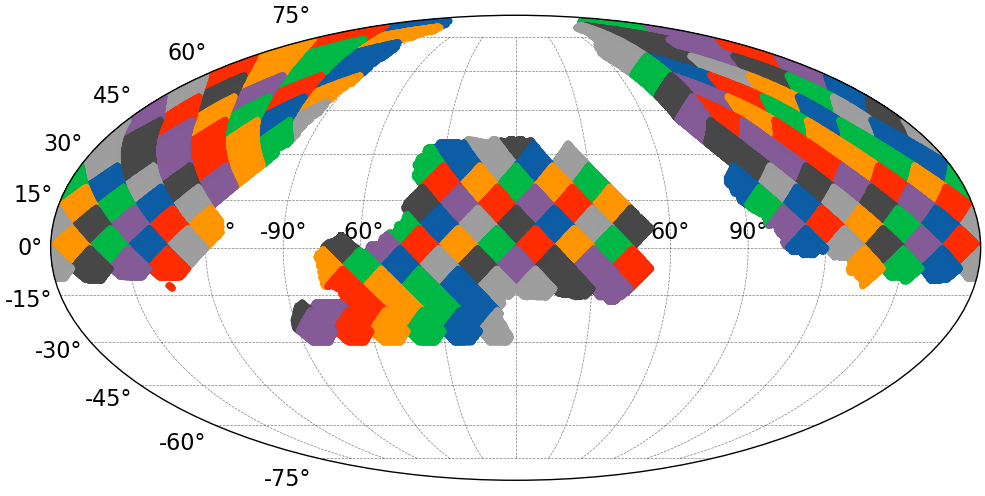

In [ ]:
nside=6
npix_random = pixelize(RA_random, DEC_random, nside=nside) ##pixels corresponding to RA AND DEC
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')

for i in jk_indexes:
    
    ra,dec=prepare_coords(RA_random[np.where(npix_random==i)],DEC_random[np.where(npix_random==i)])

    ax.plot(ra, dec, '.', alpha=0.7)


    #plt.plot(RA_random[np.where(npix_random==i)],DEC_random[np.where(npix_random==i)],'.' )

In [ ]:
#should return
npix,  jk_indexes , indexes

(array([206, 206, 206, ..., 107, 107, 107]),
 array([  1,   2,   6,   7,   8,   9,  10,  15,  16,  17,  18,  19,  20,
         21,  28,  29,  30,  31,  32,  33,  34,  35,  36,  45,  46,  47,
         48,  49,  50,  51,  52,  53,  54,  55,  66,  67,  68,  69,  70,
         71,  72,  73,  74,  75,  76,  77,  78,  84,  85,  86,  91,  92,
         93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 108, 109, 110,
        115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 130, 131,
        132, 133, 134, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
        150, 154, 155, 156, 157, 158, 164, 165, 166, 167, 168, 169, 170,
        171, 172, 173, 177, 178, 179, 180, 181, 182, 183, 188, 189, 190,
        191, 192, 193, 194, 195, 196, 197, 201, 202, 203, 204, 205, 206,
        207, 208, 212, 213, 214, 215, 216, 217, 218, 219, 220, 225, 226,
        227, 228, 229, 230, 231, 232, 233, 237, 238, 239, 240, 241, 242,
        243, 249, 250, 251, 252, 253, 254, 255, 256, 273, 274, 275, 277,
      

In [ ]:
jk_indexes

array([  1,   2,   6,   7,   8,   9,  10,  15,  16,  17,  18,  19,  20,
        21,  28,  29,  30,  31,  32,  33,  34,  35,  36,  45,  46,  47,
        48,  49,  50,  51,  52,  53,  54,  55,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  84,  85,  86,  91,  92,
        93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 108, 109, 110,
       115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 130, 131,
       132, 133, 134, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149,
       150, 154, 155, 156, 157, 158, 164, 165, 166, 167, 168, 169, 170,
       171, 172, 173, 177, 178, 179, 180, 181, 182, 183, 188, 189, 190,
       191, 192, 193, 194, 195, 196, 197, 201, 202, 203, 204, 205, 206,
       207, 208, 212, 213, 214, 215, 216, 217, 218, 219, 220, 225, 226,
       227, 228, 229, 230, 231, 232, 233, 237, 238, 239, 240, 241, 242,
       243, 249, 250, 251, 252, 253, 254, 255, 256, 273, 274, 275, 277,
       278, 279, 280, 281, 282, 300, 301, 302, 303, 304, 305])

In [ ]:
np.where(npix!=1)

(array([     0,      1,      2, ..., 480893, 480894, 480895]),)

In [ ]:
RA_data_new = RA_data[indexes]

In [ ]:
len(RA_data_new)

465943

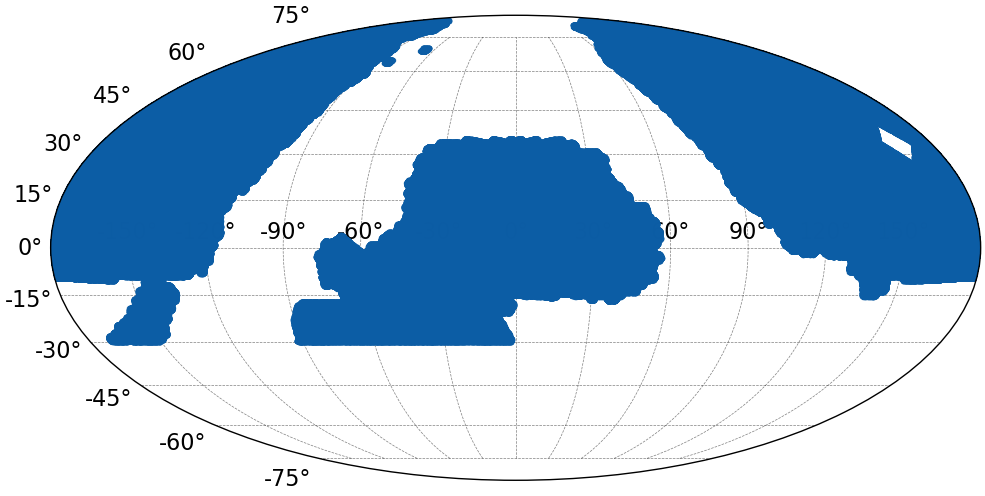

In [ ]:
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')
ra,dec=RA_random[np.where(npix_random!=97)],DEC_random[np.where(npix_random!=97)]
ra,dec=prepare_coords(ra,dec)
ax.plot(ra, dec, '.', alpha=0.7)

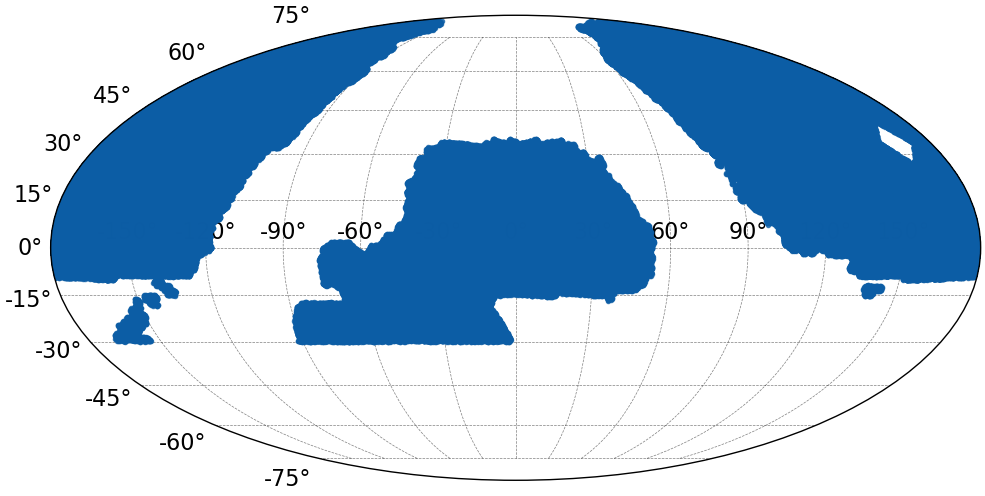

In [ ]:
fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='mollweide')
ra,dec=RA_data[np.where(npix!=97)],DEC_data[np.where(npix!=97)]
ra,dec=prepare_coords(ra,dec)
ax.plot(ra, dec, '.', alpha=0.7)



In [ ]:
counts_full[~mask.astype(bool)]

array([1541, 1232, 1654, 2112, 2145, 2233, 1688, 2904, 1889, 2087, 2624,
       2019, 3024, 3928, 2782, 2693, 1951, 2937, 2853, 2696, 2476, 2605,
       3208, 3098, 3010, 2905, 1913, 3272, 2536, 2242, 2161, 2802, 2588,
       3114, 1640, 3960, 2381, 1760, 2908, 2666, 2208, 2488, 2095, 1902,
       2474, 2618, 2492, 1803, 1168, 1354, 2714, 3527, 3546, 2522, 3341,
       3035, 3045, 2941, 4346, 4634, 4706, 3080, 2878, 2478, 1915, 2068,
       3062, 1984, 2060, 2842, 2474, 2743, 3513, 4820, 3591, 2997, 2086,
       3262, 2773, 3068, 2328, 3015, 2566, 2185, 2867, 2766, 2477, 2951,
       3980, 3273, 2001, 1539, 1892, 3246, 2466, 2506, 2377, 2668, 2368,
       2933, 3276, 3102, 2725, 2862, 2632, 2613, 1726, 1985, 2532, 2517,
       3112, 2156, 2315, 1818, 2301, 2257, 2857, 2864, 3570, 2826, 3318,
       4462, 2404, 1758, 1964, 2358, 2405, 3355, 2916, 2233, 1596, 1453,
       2684, 2259, 3472, 3423, 2994, 3472, 2667, 3267, 1621, 2584, 3239,
       2474, 2534, 3191, 2795, 1712, 2443, 1327, 19

In [ ]:
ix_sorted=np.argsort(npix)

In [ ]:
np.unique(npix,return_counts=True)

(array([  1,   2,   3,   6,   7,   8,   9,  10,  15,  16,  17,  18,  19,
         20,  21,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
         44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         60,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  83,  84,  85,  86,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 106, 107, 108, 109, 110, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 129, 130, 131,
        132, 133, 134, 135, 139, 140, 141, 142, 143, 144, 145, 146, 147,
        148, 149, 150, 153, 154, 155, 156, 157, 158, 163, 164, 165, 166,
        167, 168, 169, 170, 171, 172, 173, 176, 177, 178, 179, 180, 181,
        182, 183, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 201,
        202, 203, 204, 205, 206, 207, 208, 211, 212, 213, 214, 215, 216,
        217, 218, 219, 220, 224, 225, 226, 227, 228, 229, 230, 231, 232,
        233, 236, 237, 238, 239, 240, 241, 242, 243

In [ ]:
ix_sorted

array([ 29584,  29585,  29586, ..., 295872, 295862, 295845])

In [ ]:
np.unique(npix[ix_sorted],return_counts=True)

(array([  1,   2,   3,   6,   7,   8,   9,  10,  15,  16,  17,  18,  19,
         20,  21,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,
         44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,
         60,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  83,  84,  85,  86,  91,  92,  93,  94,  95,  96,  97,
         98,  99, 100, 101, 102, 103, 106, 107, 108, 109, 110, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 129, 130, 131,
        132, 133, 134, 135, 139, 140, 141, 142, 143, 144, 145, 146, 147,
        148, 149, 150, 153, 154, 155, 156, 157, 158, 163, 164, 165, 166,
        167, 168, 169, 170, 171, 172, 173, 176, 177, 178, 179, 180, 181,
        182, 183, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 201,
        202, 203, 204, 205, 206, 207, 208, 211, 212, 213, 214, 215, 216,
        217, 218, 219, 220, 224, 225, 226, 227, 228, 229, 230, 231, 232,
        233, 236, 237, 238, 239, 240, 241, 242, 243

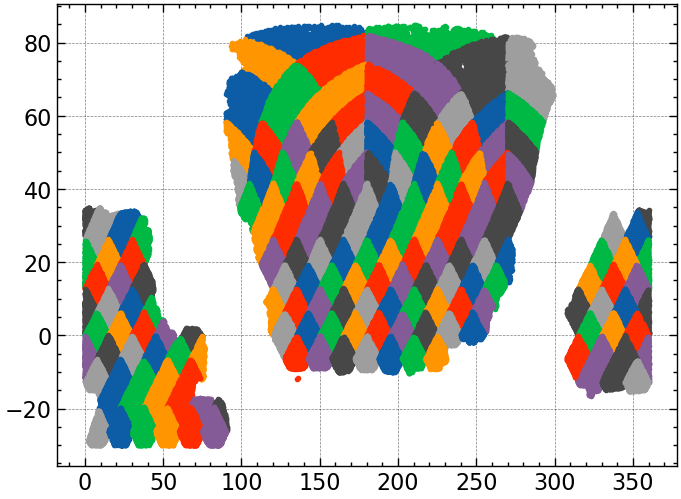

In [ ]:
#plt.plot(RA_data,DEC_data,'.' )
#plt.plot(RA_data[ix_sorted][1541:1541+1232],DEC_data[ix_sorted][1541:1541+1232],'.' )
#plt.plot(RA_data[ix_sorted][:1541],DEC_data[ix_sorted][:1541],'.' )


In [4]:
import numpy as np
import treecorr
from astropy.io import fits
import fitsio
import numpy as np
import Corrfunc
from Corrfunc.mocks.DDtheta_mocks import DDtheta_mocks
from Corrfunc.io import read_catalog
from Corrfunc.utils import convert_3d_counts_to_cf
from astropy.table import Table
from multiprocessing import Pool
import pyarrow.parquet as pq
from multiprocessing import Pool, cpu_count
import pyarrow as pa
import matplotlib.pyplot as plt
import scienceplots
import argparse
import multiprocessing
import sys
import healpy as hp
import os
from concurrent.futures import ThreadPoolExecutor, as_completed

plt.style.use(['science','notebook','grid'])


part = 'north'
method = 'corrfunc'
error = 'bootstrap'

if part=='full':
    table_selection = Table(fitsio.FITS('table_match_final.fits')[1].read())
else:
    if part == 'north':
        table_selection = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/table_north_unique_zpt_shifted_00234.fits')[1].read())
    else:
        table_selection = Table(fitsio.FITS(f'../FP_CUTS/table_{part}_unique.fits')[1].read())

if part=='north':
    table_selection = table_selection[table_selection['DEC']>=32.375]
elif part=='south':
    table_selection = table_selection[table_selection['DEC']<32.375]
RA_data,DEC_data = table_selection['RA'], table_selection['DEC']

randoms = Table(fitsio.FITS('/user/animesh.sah/FP_CUTS/randoms_5M.fits')[1].read())
if part=='north':
    rand_table = randoms[randoms['PHOTSYS']=='N']
elif part=='south':
    rand_table = randoms[randoms['PHOTSYS']=='S']
else:
    rand_table = randoms
del(randoms)
rand_table = rand_table[rand_table['DEC'] > -30]

sample_size = 5*len(table_selection)

idx = np.random.choice(len(rand_table), sample_size, replace=False)

rand_table = rand_table[idx]
RA_random,DEC_random = rand_table['RA'], rand_table['DEC'] 
RA_data   = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
DEC_data  = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))
RA_random = np.ascontiguousarray(np.array(RA_random, dtype=np.float64))
DEC_random= np.ascontiguousarray(np.array(DEC_random, dtype=np.float64))

nbins = 200
nthreads=100
min_sep = 0.001  # degrees, example
max_sep = 0.1   # degrees
N = len(RA_data)
rand_N = len(RA_random)
print('Theta value ranging from',min_sep,'to',max_sep,'in',nbins,'bins')
print('Length of data is',N)
print('Length of Random is',rand_N)
print("Ratio is:",rand_N/N)


# def w_theta_corrfunc(ra_data,dec_data,ra_random,dec_random,min_sep=0.001,max_sep=100,nbins=0,nthreads=120):
#     bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins+1 )
#     autocorr=1
#     N=len(ra)
#     N_rand = len(ra_random)
#     print(N_rand/N)
#     DD_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_data, dec_data)
#     autocorr=0
#     DR_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_data, dec_data,RA2=ra_random, DEC2=dec_random)
#     autocorr=1
#     RR_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_random,dec_random)
#     wtheta = convert_3d_counts_to_cf(N, N, rand_N, rand_N, DD_counts, DR_counts,DR_counts, RR_counts)
#     return (bins[1:]+bins[:-1])/2,wtheta

def w_theta_corrfunc(ra_data,dec_data,ra_random,dec_random,min_sep=min_sep,max_sep=max_sep,nbins=nbins,nthreads=nthreads):
    #print(ra_data)
    #print("Shape of ra data",ra_data.shape)
    bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins+1 )
    autocorr=1
    #N=len(ra)
    #N_rand = len(ra_random)
    #print(N_rand/N)

    DD_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_data, dec_data)
    autocorr=0
    DR_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_data, dec_data,RA2=ra_random, DEC2=dec_random)
    autocorr=1
    RR_counts = DDtheta_mocks(autocorr, nthreads, bins,ra_random,dec_random)
    wtheta = convert_3d_counts_to_cf(RA_data.size, RA_data.size, RA_random.size, RA_random.size, DD_counts, DR_counts,DR_counts, RR_counts)
    return (bins[1:]+bins[:-1])/2,wtheta
    




if method=='treecorr' and error=='none':
    cat_rand = treecorr.Catalog(ra=RA_random, dec=DEC_random, ra_units='deg', dec_units='deg')

    cat_data = treecorr.Catalog(ra=RA_data, dec=DEC_data, ra_units='deg', dec_units='deg')

    dd = treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg'  ,  bin_type='Log'  )# bins are spaced evenly in log10(sep)
    dr =  treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg' ,  bin_type='Log' )
    rr =  treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg' ,  bin_type='Log'  )

    dd.process(cat_data,num_threads=nthreads)
    dr.process(cat_data, cat_rand,num_threads=nthreads)
    rr.process(cat_rand,num_threads=nthreads)



    xi, varxi = dd.calculateXi(rr=rr, dr=dr)
    sig = np.sqrt(varxi)
    print('sigma',sig)
    bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins )

    #print(dd.meanr)
    #print(rr.meanr)
    #print(dd.meanr - dr.meanr)
    #print(dd.meanlogr)
    np.save(f'/user/animesh.sah/w_theta_results/treecorr_{part}_{min_sep}_to_{max_sep}.npy', np.vstack([dd.meanr,xi,sig]))

elif method=='corrfunc' and error=='none':

    bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins+1 )
    autocorr=1
    N=len(RA_data)
    print('Starting code')
    print('Length of data is',N)
    print('Length of Random is',rand_N)
    print("Ratio is:",rand_N/N)
    DD_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_data, DEC_data)
    autocorr=0
    print('Done with DD counts')
    DR_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_data, DEC_data,RA2=RA_random, DEC2=DEC_random)
    autocorr=1
    RR_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_random,DEC_random)
    wtheta = convert_3d_counts_to_cf(RA_data.size, RA_data.size, RA_random.size, RA_random.size, DD_counts, DR_counts,DR_counts, RR_counts)
    print('W_theta',wtheta)
    np.save(f'/user/animesh.sah/w_theta_results/corrfunc_{part}_{min_sep}_to_{max_sep}.npy', np.vstack([(bins[1:]+bins[:-1])/2,wtheta]))

def hist_pix(ra,dec,nside=6):
    npix = hp.nside2npix(nside)
    pix = hp.ang2pix(nside, np.radians(90.-dec), np.radians(ra), lonlat=False)
    counts = np.bincount(pix, minlength=npix)
    return counts

def pixelize(ra,dec,nside=6):
    theta = np.ascontiguousarray((np.pi/2.0 - np.deg2rad(dec)).astype(np.float64))
    phi   = np.ascontiguousarray(np.deg2rad(ra).astype(np.float64))
    hpix = hp.ang2pix(nside, theta, phi,nest=False)
    return hpix
def prepare_jackknife(RA,DEC,nside=6):
    # takes in RA and DEC and returns the pixel indices and the usable indexes for jackknife
    counts=hist_pix(RA,DEC,nside=nside)
    counts_full = np.copy(counts)
    counts = counts[counts>0]
    mean = np.mean(counts)
    threshold = mean/2
    #counts_full = hist_pix(RA_data, DEC_data, nside=nside)
    mask = counts_full < threshold
    plot_map = mask.astype(float)   
    npix = pixelize(RA, DEC, nside=nside) ##pixels corresponding to RA AND DEC
    pixels = np.arange(0,12*nside**2)
    jk_indexes = pixels[~plot_map.astype(bool)]    ## pixels which can be used for jackknife
    indexes = np.where(np.isin(npix,jk_indexes))[0] ##indexes of the RA AND DEC which can be used for jackknife
    print('Total number of usable pixles are:',len(counts_full[~mask.astype(bool)]))
    return npix,jk_indexes, indexes

def leave_one_out_data(RA,DEC,index,nside=6):
    # takes in RA and DEC and the index of the pixel to be removed
    # returns the RA and DEC after removing the pixel
    npix,jk_indexes,indexes = prepare_jackknife(RA,DEC,nside=nside)
    mask = npix != index
    return RA[mask], DEC[mask]
def leave_one_out_random(RA,DEC,index,nside=6):
    # takes in RA and DEC and the index of the pixel to be removed
    # returns the RA and DEC after removing the pixel
    npix_random = pixelize(RA, DEC, nside=nside) ##pixels corresponding to RA AND DEC
    mask = npix_random != index
    return RA[mask], DEC[mask]


def w_bootstrapp(seed ):
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(table_selection), int(len(table_selection)/10), replace=True)
    sampled = table_selection[idx]
    bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins+1 )
    RA_data, DEC_data = sampled['RA'], sampled['DEC']
    RA_data = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
    DEC_data = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))
    print('done with sampling')
    print('max_sep',max_sep)
    print('min_sep',min_sep)
    print('nbins',nbins)
    print('length of RA data',len(RA_data)  )
    autocorr = 1
    DD_counts = DDtheta_mocks(autocorr, nthreads, bins, RA_data, DEC_data)
    print('Done with DD counts')
    autocorr = 0
    DR_counts = DDtheta_mocks(
        autocorr, nthreads, bins,
        RA_data, DEC_data,
        RA2=RA_random, DEC2=DEC_random
    )

    wtheta_boot = convert_3d_counts_to_cf(
        RA_data.size, RA_data.size, RA_random.size, RA_random.size,
        DD_counts, DR_counts,
        DR_counts, RR_counts
    )
    return wtheta_boot





num_bootstrap = 1
autocorr=1 
bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins+1 )

RR_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_random, DEC_random)
print('Done with RR counts')
seeds = np.random.SeedSequence().spawn(num_bootstrap)  # unique RNG seeds
rng = np.random.default_rng(seeds[0])

idx = np.random.choice(len(table_selection), int(len(table_selection)/10), replace=True)
sampled = table_selection[idx]

bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins+1 )

RA_data,DEC_data = sampled['RA'], sampled['DEC']
RA_data = np.ascontiguousarray(np.array(RA_data, dtype=np.float64))
DEC_data = np.ascontiguousarray(np.array(DEC_data, dtype=np.float64))
print('RA_data is', RA_data)
np.save('RA_data.npy', RA_data)
np.save('DEC_data.npy', DEC_data)
print('DEC_data is', DEC_data)

autocorr = 1
DD_counts = DDtheta_mocks(autocorr, nthreads, bins, RA_data, DEC_data)

print('DD counts',DD_counts)
autocorr = 0
DR_counts = DDtheta_mocks(autocorr, nthreads, bins,RA_data, DEC_data,RA2=RA_random, DEC2=DEC_random)
print('DR counts',DR_counts)

# Correlation function
wtheta_boot = convert_3d_counts_to_cf(RA_data.size, RA_data.size, RA_random.size, RA_random.size,
                                    DD_counts, DR_counts,
                                    DR_counts, RR_counts)
print('Done with wtheta')





#print(seeds)
#print([int(s.generate_state(1)[0]) for s in seeds])
# with multiprocessing.Pool(processes=1) as pool:
#     w_boot = pool.starmap(w_bootstrapp, [(s,) for s in seeds])







        




Theta value ranging from 0.001 to 0.1 in 200 bins
Length of data is 140673
Length of Random is 703365
Ratio is: 5.0
Done with RR counts
RA_data is [245.71227976 250.45715691 259.90854685 ... 211.94671179 246.31523561
 270.11746332]
DEC_data is [55.83749372 74.75030673 65.91353273 ... 35.6916046  51.65776493
 48.37113924]
DD counts [(0.001     , 0.00102329, 0.,   0, 0.)
 (0.00102329, 0.00104713, 0.,   0, 0.)
 (0.00104713, 0.00107152, 0.,   0, 0.)
 (0.00107152, 0.00109648, 0.,   0, 0.)
 (0.00109648, 0.00112202, 0.,   0, 0.)
 (0.00112202, 0.00114815, 0.,   0, 0.)
 (0.00114815, 0.0011749 , 0.,   0, 0.)
 (0.0011749 , 0.00120226, 0.,   0, 0.)
 (0.00120226, 0.00123027, 0.,   0, 0.)
 (0.00123027, 0.00125893, 0.,   0, 0.)
 (0.00125893, 0.00128825, 0.,   0, 0.)
 (0.00128825, 0.00131826, 0.,   0, 0.)
 (0.00131826, 0.00134896, 0.,   0, 0.)
 (0.00134896, 0.00138038, 0.,   0, 0.)
 (0.00138038, 0.00141254, 0.,   0, 0.)
 (0.00141254, 0.00144544, 0.,   0, 0.)
 (0.00144544, 0.00147911, 0.,   0, 0.)
 (0.

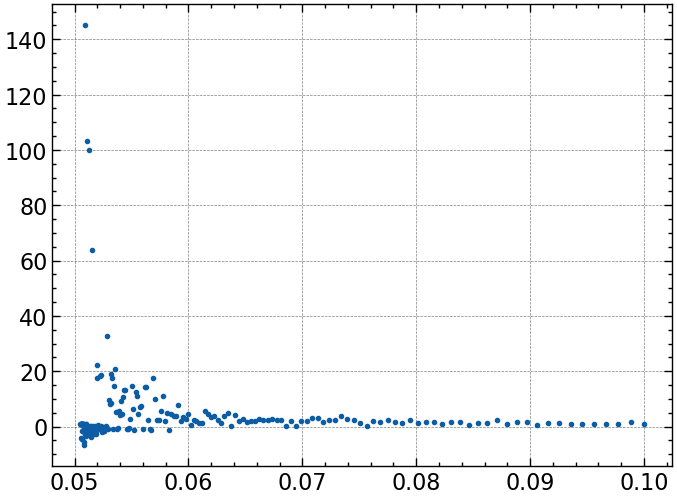

In [19]:
plt.plot((bins[1:]+bins[-1])/2,wtheta_boot,'.')

In [ ]:
import healpy as hp
import numpy as np
import healpy.visufunc as hv

nside =64
npix = hp.nside2npix(nside)

theta = np.radians(90.0 - dec_array.data)  # theta = 0 at North Pole
phi = np.radians(ra_array.data) 
pix_indices = hp.ang2pix(nside, theta, phi)
hpx_map = np.zeros(npix, dtype=int)

ix,counts=np.unique(pix_indices,return_counts=True)
   # fill the fullsky map
hpx_map = np.zeros(npix, dtype=int)
hpx_map[ix] = counts
hp.mollview(hpx_map,cmap='Blues', unit='Counts',norm='hist',title=f"Histogram equalized Sky Map (nside={nside})")
hp.graticule()

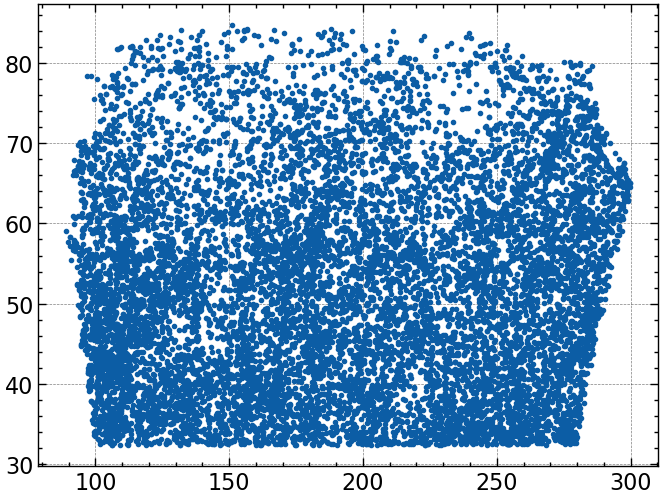

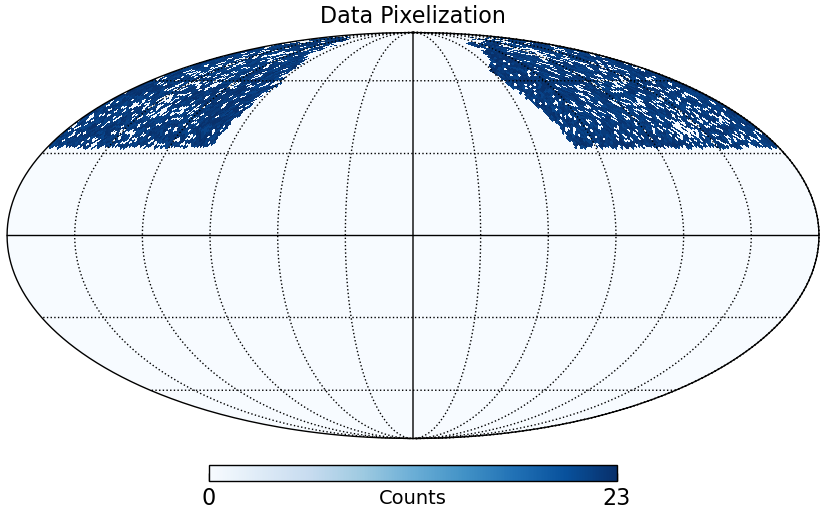

In [ ]:
plt.plot(RA_data,DEC_data,'.'   )
nside=64
npix = hp.nside2npix(nside)

theta_data = np.radians(90.0 - DEC_data)  # theta = 0 at North Pole
phi_data = np.radians(RA_data)  
hpx_map = np.zeros(npix, dtype=int)

pix_indices = hp.ang2pix(nside, theta_data, phi_data,nest=False)
ix,counts=np.unique(pix_indices,return_counts=True)
hpx_map = np.zeros(npix, dtype=int)
hpx_map[ix] = counts
hp.mollview(hpx_map, title='Data Pixelization', cmap='Blues', cbar=True, unit='Counts', norm='hist')
hp.graticule()
hp.mollview(hpx_map, title='Data Pixelization', cmap='Blues', cbar=True, unit='Counts', norm='hist')
hp.graticule()

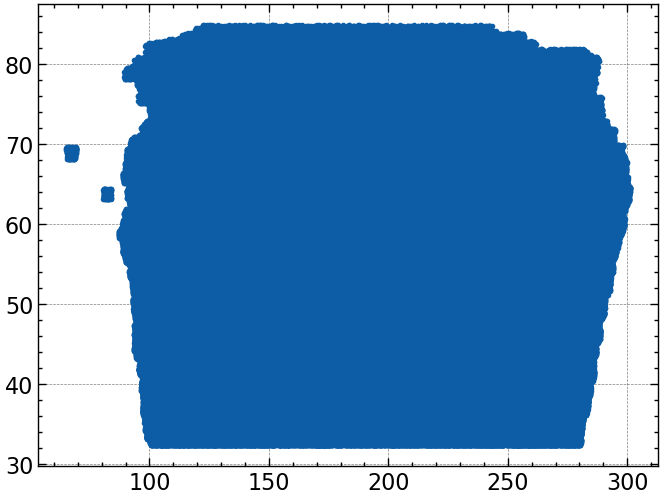

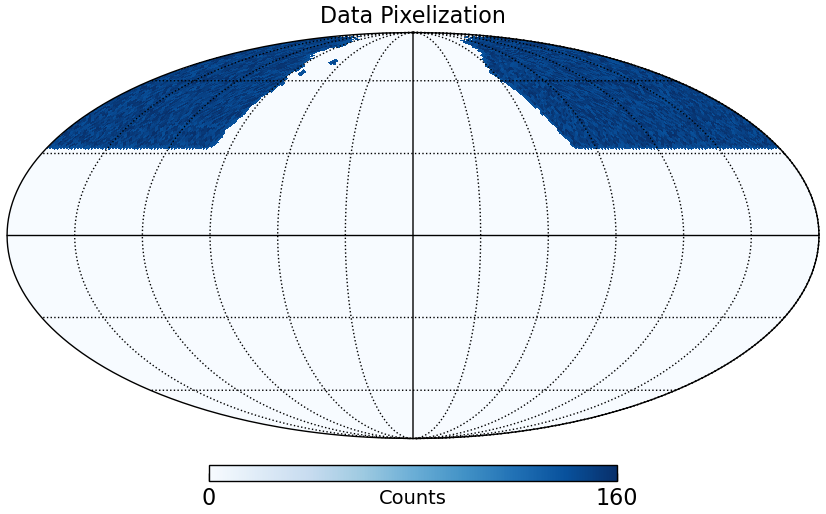

In [15]:
plt.plot(RA_random,DEC_random,'.'   )
nside=64
npix = hp.nside2npix(nside)

theta_data = np.radians(90.0 - DEC_random)  # theta = 0 at North Pole
phi_data = np.radians(RA_random)  
hpx_map = np.zeros(npix, dtype=int)

pix_indices = hp.ang2pix(nside, theta_data, phi_data,nest=False)
ix,counts=np.unique(pix_indices,return_counts=True)
hpx_map = np.zeros(npix, dtype=int)
hpx_map[ix] = counts
hp.mollview(hpx_map, title='Data Pixelization', cmap='Blues', cbar=True, unit='Counts', norm='hist')
hp.graticule()

In [ ]:
cat_rand = treecorr.Catalog(ra=RA_random, dec=DEC_random, ra_units='deg', dec_units='deg')

cat_data = treecorr.Catalog(ra=RA_data, dec=DEC_data, ra_units='deg', dec_units='deg')

dd = treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg'  ,  bin_type='Log'  )# bins are spaced evenly in log10(sep)
dr =  treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg' ,  bin_type='Log' )
rr =  treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins ,sep_units='deg' ,  bin_type='Log'  )

dd.process(cat_data,num_threads=nthreads)
dr.process(cat_data, cat_rand,num_threads=nthreads)
rr.process(cat_rand,num_threads=nthreads)



xi, varxi = dd.calculateXi(rr=rr, dr=dr)

bins = np.logspace(np.log10(min_sep), np.log10(max_sep), nbins )

sigma [36.07734168 22.81731433 22.81731433 18.03867084 22.81731433 15.38343018
 16.13427769 14.72851307 17.00702197 13.17358257 15.38343018 14.72851307
 17.00702197 11.40865716 11.40865716 14.72851307 13.17358257 10.41463147
 13.17358257 14.15069763 13.17358257 15.38343018 10.8777278  10.41463147
 10.00605425 12.37442611 10.00605425  9.31512957  9.16365395 10.41463147
 10.8777278  10.20421318  9.16365395 10.41463147  8.88162756  7.87272139
  9.31512957  7.2887237   8.75004061  7.2887237   7.52264576  6.94308764
  7.52264576  7.07534882  7.87272139  6.37763324  6.37763324  6.53257809
  5.77699812  5.97156408  5.93107844  5.93107844  6.18721305  5.29063808
  5.93107844  6.75790527  5.34846097  5.70432858  4.79965814  4.4748435
  4.90950436  4.955604    5.027255    4.45773123  4.49215437  4.49215437
  3.9962783   3.96000271  4.22253346  3.9840759   3.96000271  3.80288572
  3.73102985  3.45558262  3.37156694  3.20766693  3.23332867  3.33535142
  3.03288756  3.11660764  3.18260665  3.110809

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -8.88178420e-16,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -8.88178420e-16, -2.22044605e-16,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00, -2.22044605e-16,  0.00000000e+00,  0.00000000e+00,
       -8.88178420e-16,  0.00000000e+00,  0.00000000e+00, -2.22044605e-16,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.11022302e-16,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -4.44089210e-16,  0.00000000e+00,  0.00000000e+00, -2.22044605e-16,
        0.00000000e+00,  2.08166817e-17, -1.66533454e-16,  0.00000000e+00,
        2.22044605e-16, -1.11022302e-16,  0.00000000e+00,  0.00000000e+00,
       -4.44089210e-16, -2.77555756e-17, -4.44089210e-16, -6.66133815e-16,
        0.00000000e+00, -4.44089210e-16,  0.00000000e+00, -2.22044605e-16,
       -4.44089210e-16, -